## Analysis of Flood Direct and Indirect Climate Impacts on the Trans-European Transport Network (TEN-T)

This analysis examines the risk and expected direct damages and indirect loses of TEN-T corridor infrastructure to climate hazards, with specific focus on:

1. **Spatial distribution of exposed assets**: Mapping the location and extent of TEN-T infrastructure across different transport modes
2. **Flow-weighted criticality assessment**: Identifying high-priority infrastructure based on freight and passenger volumes and connected industrial activity
3. **Hazard exposure quantification**: Assessing infrastructure exposure to flooding events across different return periods
4. **Economic impact evaluation**: Quantifying direct and indirect loses, Expected Annual Damage (EAD) and Expected Annual Indirect Loses (EAIL) under current and future climate scenarios

## 1.1 Setup and Configuration

This section initializes the analysis environment by loading libraries, defining the 10 TEN-T corridors, and preparing base geographic data.

**Loaded data:**
- **European country boundaries**: Base map for spatial context
- **TEN-T corridor definitions**: 9 major corridors (A–L) with unique colors for identification
- **Utility functions**: Custom corridor extraction and visualization tools

In [1]:
import os
import re
import warnings
from pathlib import Path
from time import perf_counter
from scipy.interpolate import interp1d

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import rasterio
from rasterio.plot import show
from rasterio.enums import Resampling
from matplotlib import colors
import openpyxl
from shapely import wkb, wkt

warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Import corridor utilities (loaded once at startup)
import importlib
import corridor_utils as _corridor_utils

# Helper aliases from corridor_utils used across notebook
_pick_existing = _corridor_utils._pick_existing
_timed_load = _corridor_utils._timed_load
_coerce_loaded_geo = _corridor_utils._coerce_loaded_geo
assign_primary_corridor = _corridor_utils.assign_primary_corridor
_bounds_with_padding = _corridor_utils._bounds_with_padding
_infer_and_fix_crs = _corridor_utils._infer_and_fix_crs
build_study_area = _corridor_utils.build_study_area
_read_parquet_as_gdf = _corridor_utils._read_parquet_as_gdf
_safe_read_parquet_any = _corridor_utils._safe_read_parquet_any
_compute_disruption_cost_eur = _corridor_utils._compute_disruption_cost_eur
build_country_loss_plot_df = _corridor_utils.build_country_loss_plot_df
plot_country_loss_grouped_bars = _corridor_utils.plot_country_loss_grouped_bars

# Import tent_utils visualization functions
from tent_utils import (
    extract_corridors,
    setup_ax,
    get_linewidth_freight,
    get_linewidth_passenger,
    get_markersize_freight,
    get_markersize_passenger,
    plot_by_corridor_and_visual_attr,
    reproject_raster_to_3035,
    aggregate_by_location,
    create_flow_legend,
    load_infrastructure_parquet,
    reproject_infrastructure_dict,
    merge_risk_data_preserve_geometry,
    format_log_colorbar
)

# Corridor palette for TEN-T corridor plots
corridor_order = ['A', 'B', 'C', 'E', 'G', 'I', 'J', 'K', 'L', 'U']
corridor_names = {
    'A': 'Baltic - Adriatic',
    'B': 'North Sea - Baltic',
    'C': 'Mediterranean',
    'E': 'Scandinavian - Mediterranean',
    'G': 'Atlantic',
    'I': 'Rhine-Danube',
    'J': 'Baltic Sea - Black Sea - Aegean Sea',
    'K': 'W. Balkans-E. Mediterranean',
    'L': 'North Sea - Rhine - Mediterranean',
    'U': 'Not-in-corridor',
}
corridor_colors = {
    'A': '#0080C0',
    'B': '#E91E1E',
    'C': '#00A651',
    'E': '#FF69B4',
    'G': '#FFD700',
    'I': '#00BFFF',
    'J': '#8B4789',
    'K': '#8B4513',
    'L': '#003A0A',
    'U': '#b3b3b3',
}

# Corridor configuration and paths
TARGET_CORRIDOR_LABEL = globals().get('TARGET_CORRIDOR_LABEL', 'Rhine-Alpine')
TARGET_CORRIDOR_DATA_LABEL = globals().get('TARGET_CORRIDOR_DATA_LABEL', 'rhine-alpine')
TARGET_CORRIDOR_CODE = globals().get('TARGET_CORRIDOR_CODE', 'RALP')
TARGET_CORRIDOR_BUFFER_M = globals().get('TARGET_CORRIDOR_BUFFER_M', 50_000)
INCLUDE_IWW = globals().get('INCLUDE_IWW', True)

# ─────────────────────────────────────────────────────────────────────────────
# Path setup: corridor data directories
# ─────────────────────────────────────────────────────────────────────────────
# Data root
code_dir = Path.cwd()
root = code_dir.parent
output_dir = root / "outputs"
data_root = root / "data"
corridor_root = root / "inputs" / "country_data" / "Corridors_NUTS2" / "rhine-alpine"
flows = root / "inputs" / 'europe_corridors_with_flows'
infra = root / "inputs" / 'europe_corridors_with_flows'
selected_flows = corridor_root / 'Flows'
selected_infra = corridor_root / 'Infra'
industries = corridor_root / 'industries'
selected_nuts_dir = corridor_root

# Unified directory references
country_data_dir_local = corridor_root
country_data_dir = corridor_root
flows_dir = flows
infra_dir = infra  # Europe-wide infra (plotting + direct damage)
selected_flows_dir = selected_flows
selected_infra_dir = selected_infra  # Corridor infra (indirect loss)
industries_dir = industries
selected_nuts_dir = selected_nuts_dir
selected_nuts2_file = selected_nuts_dir / 'selected_nuts2.parquet'

# Separate infra roots by analysis purpose
europe_infra_dir = infra_dir
corridor_infra_dir = selected_infra_dir

# Europe-wide infrastructure file map (corridor plotting + direct damage)
infrastructure_files = {
    'railway_edges': europe_infra_dir / 'europe_railways_edges_TENT.parquet',
    'road_edges': europe_infra_dir / 'europe_road_edges_TENT.parquet',
    'iww_edges': europe_infra_dir / 'europe_iww_edges_TENT.parquet',
    'railway_stations': europe_infra_dir / 'europe_railways_stations_TENT.parquet',
    'iww_nodes': europe_infra_dir / 'europe_iww_nodes_TENT.parquet',
    'ports': europe_infra_dir / 'europe_ports_TENT.parquet',
    'airports': europe_infra_dir / 'europe_airports_TENT.parquet',
}

# Corridor-specific infrastructure file map (indirect loss)
corridor_infrastructure_files = {
    'railway_edges': corridor_infra_dir / 'europe_railways_edges_TENT.parquet',
    'road_edges': corridor_infra_dir / 'europe_road_edges_TENT.parquet',
    'iww_edges': corridor_infra_dir / 'europe_iww_edges_TENT.parquet',
    'railway_stations': corridor_infra_dir / 'europe_railways_stations_TENT.parquet',
    'iww_nodes': corridor_infra_dir / 'europe_iww_nodes_TENT.parquet',
    'ports': corridor_infra_dir / 'europe_ports_TENT.parquet',
    'airports': corridor_infra_dir / 'europe_airports_TENT.parquet',
}

# Hazard data directory (for enrichment workflow)
hazard_dir = root / "inputs" / "climate_hazards"
impact_dir = hazard_dir / 'Corridors' / 'rhine-alpine'

# Update globals for downstream cells
globals().update({
    'code_dir': code_dir,
    'country_data_dir_local': country_data_dir_local,
    'country_data_dir': country_data_dir,
    'flows_dir': flows_dir,
    'infra_dir': infra_dir,
    'selected_flows_dir' : selected_flows_dir,
    'selected_infra_dir' : selected_infra_dir, 
    'industries_dir': industries_dir,
    'selected_nuts_dir': selected_nuts_dir,
    'selected_nuts2_file': selected_nuts2_file,
    'hazard_dir': hazard_dir,
    'impact_dir': impact_dir,
    'europe_infra_dir': europe_infra_dir,
    'corridor_infra_dir': corridor_infra_dir,
    'infrastructure_files': infrastructure_files,
    'corridor_infrastructure_files': corridor_infrastructure_files,
    'corridor_order': corridor_order,
    'corridor_names': corridor_names,
    'corridor_colors': corridor_colors,
})

# Load Europe country boundaries for base maps (used by setup_ax and map cells)
europe_candidates = [
    data_root / 'ne_10m' / 'ne_10m_admin_0_countries.shp'
]

europe_file = _pick_existing(europe_candidates)
if europe_file.exists():
    europe_countries = gpd.read_file(europe_file)
    if europe_countries.crs is None:
        europe_countries = europe_countries.set_crs('EPSG:4326', allow_override=True)
    print(f'Europe boundaries loaded: {len(europe_countries):,} features from {europe_file}')
else:
    europe_countries = gpd.GeoDataFrame()
    print(f'[WARN] Europe boundaries not found. Checked: {europe_candidates}')

globals().update({
    'europe_countries': europe_countries,
})

Europe boundaries loaded: 258 features from \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\data\ne_10m\ne_10m_admin_0_countries.shp


## 1.2 Load Infrastructure Data

This section loads geospatial infrastructure datasets for all transport modes across the TEN-T network.

**Infrastructure types loaded:**
- **Railway edges**: Network segments with freight and passenger flow data
- **Railway stations**: Hub locations and capacities
- **Road edges**: Network segments (where available)
- **Ports**: Maritime terminals with cargo and passenger volumes
- **Airports**: Air transport hubs with freight and passenger volumes
- **Inland waterways (IWW)**: River and canal transport routes with associated nodes

In [2]:
print("Loading infrastructure data...\n")

infrastructure_europe = {}
for infra_type, file_path in infrastructure_files.items():
    gdf = load_infrastructure_parquet(file_path, infra_type)
    if gdf is not None:
        infrastructure_europe[infra_type] = gdf

print(f"\nLoaded {len(infrastructure_europe)} Europe-wide infrastructure types")

infrastructure_europe = reproject_infrastructure_dict(infrastructure_europe)
for infra_type, gdf in infrastructure_europe.items():
    if 'CORRIDORS' in gdf.columns:
        gdf['corridor_list'] = gdf['CORRIDORS'].apply(extract_corridors)
        gdf['primary_corridor'] = gdf['corridor_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
        print(f"{infra_type}: {gdf['primary_corridor'].nunique()} unique primary corridors")

infrastructure = infrastructure_europe
globals().update({
    'infrastructure_europe': infrastructure_europe,
    'infrastructure': infrastructure,
})

LOAD_PATH_TABLES = False
print(f'Europe-wide infra dir (plot/direct): {europe_infra_dir}')
print(f'Corridor infra dir (indirect):      {corridor_infra_dir}')
print(f'  Flows: {flows_dir}')

nuts2_candidates = [
    globals().get('selected_nuts2_file', selected_nuts_dir / 'selected_nuts2.parquet'),
    selected_nuts_dir / 'selected_nuts2.parquet',
    country_data_dir / 'selected_nuts2.parquet',
    country_data_dir_local / 'selected_nuts2.parquet',
    data_root / 'country_data' / 'Corridors_NUTS2' / 'rhine-alpine' / 'selected_nuts2.parquet',
]

setup_ctx = _corridor_utils.prepare_corridor_data_context(
    corridor_infrastructure_files=corridor_infrastructure_files,
    infrastructure_files=infrastructure_files,
    nuts2_candidates=nuts2_candidates,
    include_iww=INCLUDE_IWW,
    target_corridor_label=TARGET_CORRIDOR_LABEL,
    target_corridor_code=TARGET_CORRIDOR_CODE,
    target_corridor_data_label=TARGET_CORRIDOR_DATA_LABEL,
    target_corridor_buffer_m=TARGET_CORRIDOR_BUFFER_M,
    target_crs='EPSG:4326',
)

globals().update(setup_ctx)

rail_edges = setup_ctx['rail_edges']
road_edges = setup_ctx['road_edges']
iww_edges = setup_ctx['iww_edges']
rail_stations = setup_ctx['rail_stations']
iww_nodes = setup_ctx['iww_nodes']
ports = setup_ctx['ports']
airports = setup_ctx['airports']
iww_ports = setup_ctx['iww_ports']
study_area = setup_ctx['study_area']
country_row = setup_ctx['country_row']
xlim, ylim = setup_ctx['xlim'], setup_ctx['ylim']
nuts2 = setup_ctx['nuts2']
infra_vars = setup_ctx['infra_vars']

Loading infrastructure data...

railway_edges       : 739,849 features
road_edges          : 277,820 features
iww_edges           : 60,087 features
railway_stations    :  9,286 features
iww_nodes           : 117,881 features
ports               :  4,441 features
airports            :    116 features

Loaded 7 Europe-wide infrastructure types
railway_edges: 9 unique primary corridors
road_edges: 9 unique primary corridors
iww_edges: 5 unique primary corridors
railway_stations: 9 unique primary corridors
iww_nodes: 6 unique primary corridors
ports: 10 unique primary corridors
airports: 9 unique primary corridors
Europe-wide infra dir (plot/direct): \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\inputs\europe_corridors_with_flows
Corridor infra dir (indirect):      \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\inputs\country_data\Corridors_NUTS2\rhine-alpine\Infra
  Flows: \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\inputs\europ

# 2. Lifelines identification

## 2.1 Visualize All Assets by Corridor

This map displays the complete geographic extent of TEN-T infrastructure across all modes and corridors, revealing multimodal hubs and regional patterns.

**Map legend:**
- **Network edges**: Railway (thin line), roads (dashed), inland waterways (dash-dot)
- **Node facilities**: Ports (circles), airports (triangles), railway stations (squares)
- **Color coding**: Each corridor has a unique color for easy identification

This overview enables visual identification of critical infrastructure concentrations and multimodal interchange points.

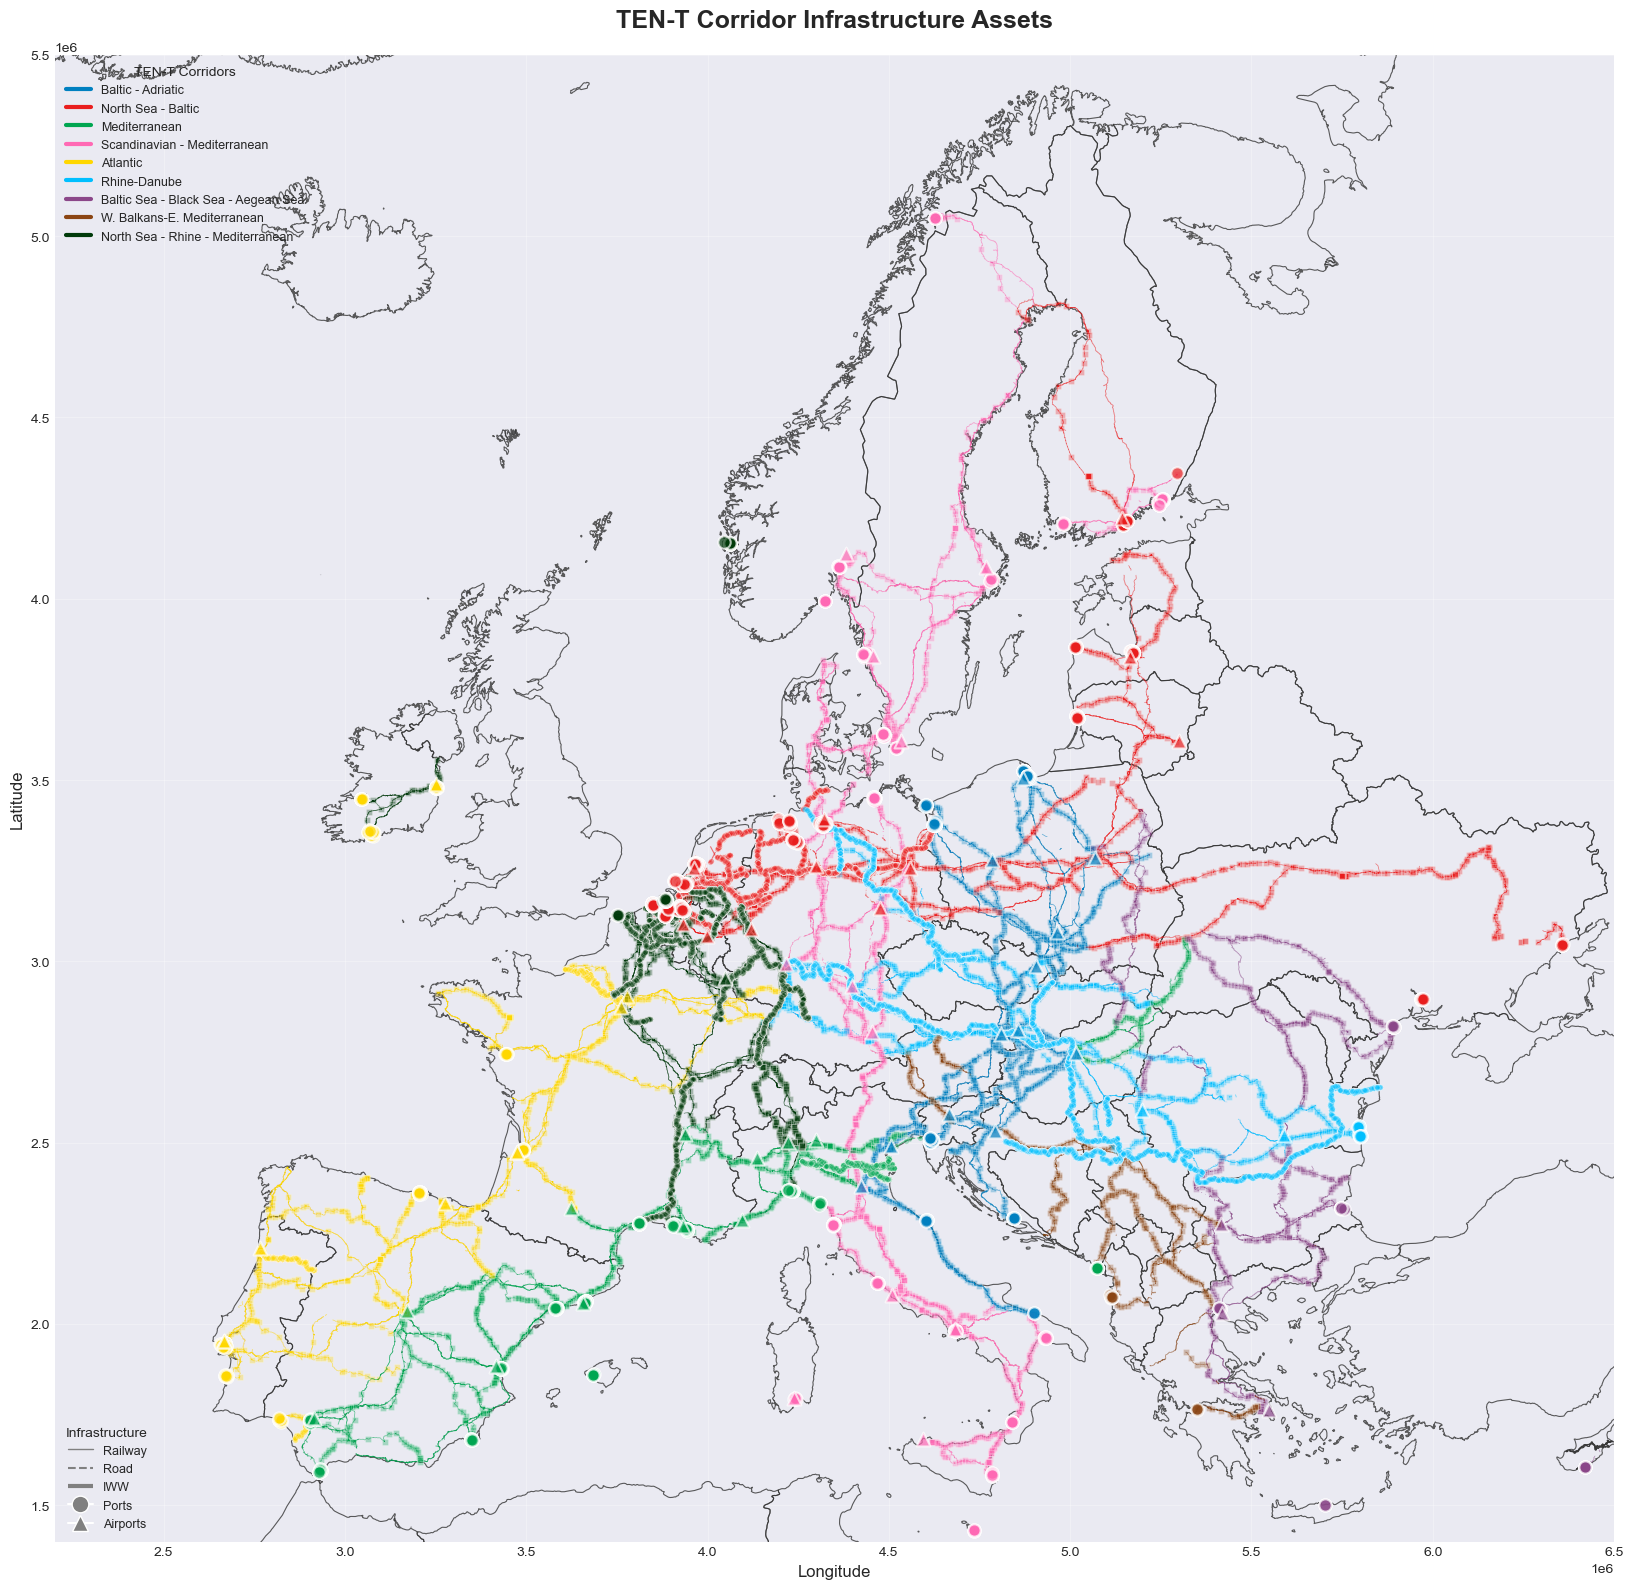

<Figure size 640x480 with 0 Axes>

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(20, 16))

# Use utility function to set up the map
setup_ax(ax, europe_countries, infrastructure)

# Plot edges (railway, road, and IWW)
for infra_type in ['railway_edges', 'road_edges', 'iww_edges']:
    if infra_type in infrastructure:
        gdf = infrastructure[infra_type]
        if infra_type == 'railway_edges':
            linewidth = 0.5
        elif infra_type == 'road_edges':
            linewidth = 0.6
        else:  # iww_edges
            linewidth = 0.8
        
        for corridor in corridor_colors.keys():
            mask = gdf['primary_corridor'] == corridor
            if mask.any():
                gdf[mask].plot(
                    ax=ax,
                    color=corridor_colors[corridor],
                    linewidth=linewidth,
                    alpha=0.6,
                    zorder=2
                )

# Plot nodes (ports, airports, railway stations)
for infra_type in ['ports', 'airports', 'railway_stations', 'iww_nodes']:
    if infra_type in infrastructure:
        gdf = infrastructure[infra_type]
        
        marker = 'o' if infra_type in ['ports', 'iww_nodes'] else ('^' if infra_type == 'airports' else 's')
        size = 100 if infra_type == 'airports' else (80 if infra_type == 'ports' else 15)
        
        for corridor in corridor_colors.keys():
            mask = gdf['primary_corridor'] == corridor
            if mask.any():
                gdf[mask].plot(
                    ax=ax,
                    color=corridor_colors[corridor],
                    marker=marker,
                    markersize=size,
                    alpha=0.7 if infra_type in ['airports', 'ports'] else 0.3,
                    edgecolor='white',
                    linewidth=1.5 if infra_type in ['airports', 'ports'] else 0.5,
                    zorder=4 if infra_type in ['airports', 'ports'] else 3
                )

# Create legends
corridor_elements = [Line2D([0], [0], color=corridor_colors[code], lw=3, 
                            label=corridor_names[code]) 
                     for code in corridor_order if code != 'U']

infra_elements = [
    Line2D([0], [0], color='gray', lw=1, label='Railway'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label='Road'),
    Line2D([0], [0], color='gray', lw=3, linestyle='-.', label='IWW'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
           markersize=12, label='Ports', markeredgecolor='white'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', 
           markersize=12, label='Airports', markeredgecolor='white')
]

legend1 = ax.legend(handles=corridor_elements, title='TEN-T Corridors', 
                   loc='upper left', fontsize=9, title_fontsize=10)
ax.add_artist(legend1)
ax.legend(handles=infra_elements, title='Infrastructure', 
         loc='lower left', fontsize=9, title_fontsize=10)

ax.set_title('TEN-T Corridor Infrastructure Assets', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

plt.tight_layout()
plt.show()

plt.savefig(output_dir / 'tent_assets.png')

## 2.2 Freight Flows Visualization

These maps reveal where high-volume freight movements are concentrated across the TEN-T network. Major corridors  show elevated volumes due to their central European position and industrial connectivity.

**Visualization method:**
- **Four panels**: One for each transport mode (rail, IWW, ports, airports)
- **Line width**: Proportional to annual freight volume (MT/year); thicker = higher tonnage
- **Bubble size**: Proportional to total annual freight handled; larger = higher capacity

Identifying freight corridors helps prioritize disruption planning and adaptation efforts.

Preparing freight flow visualization...



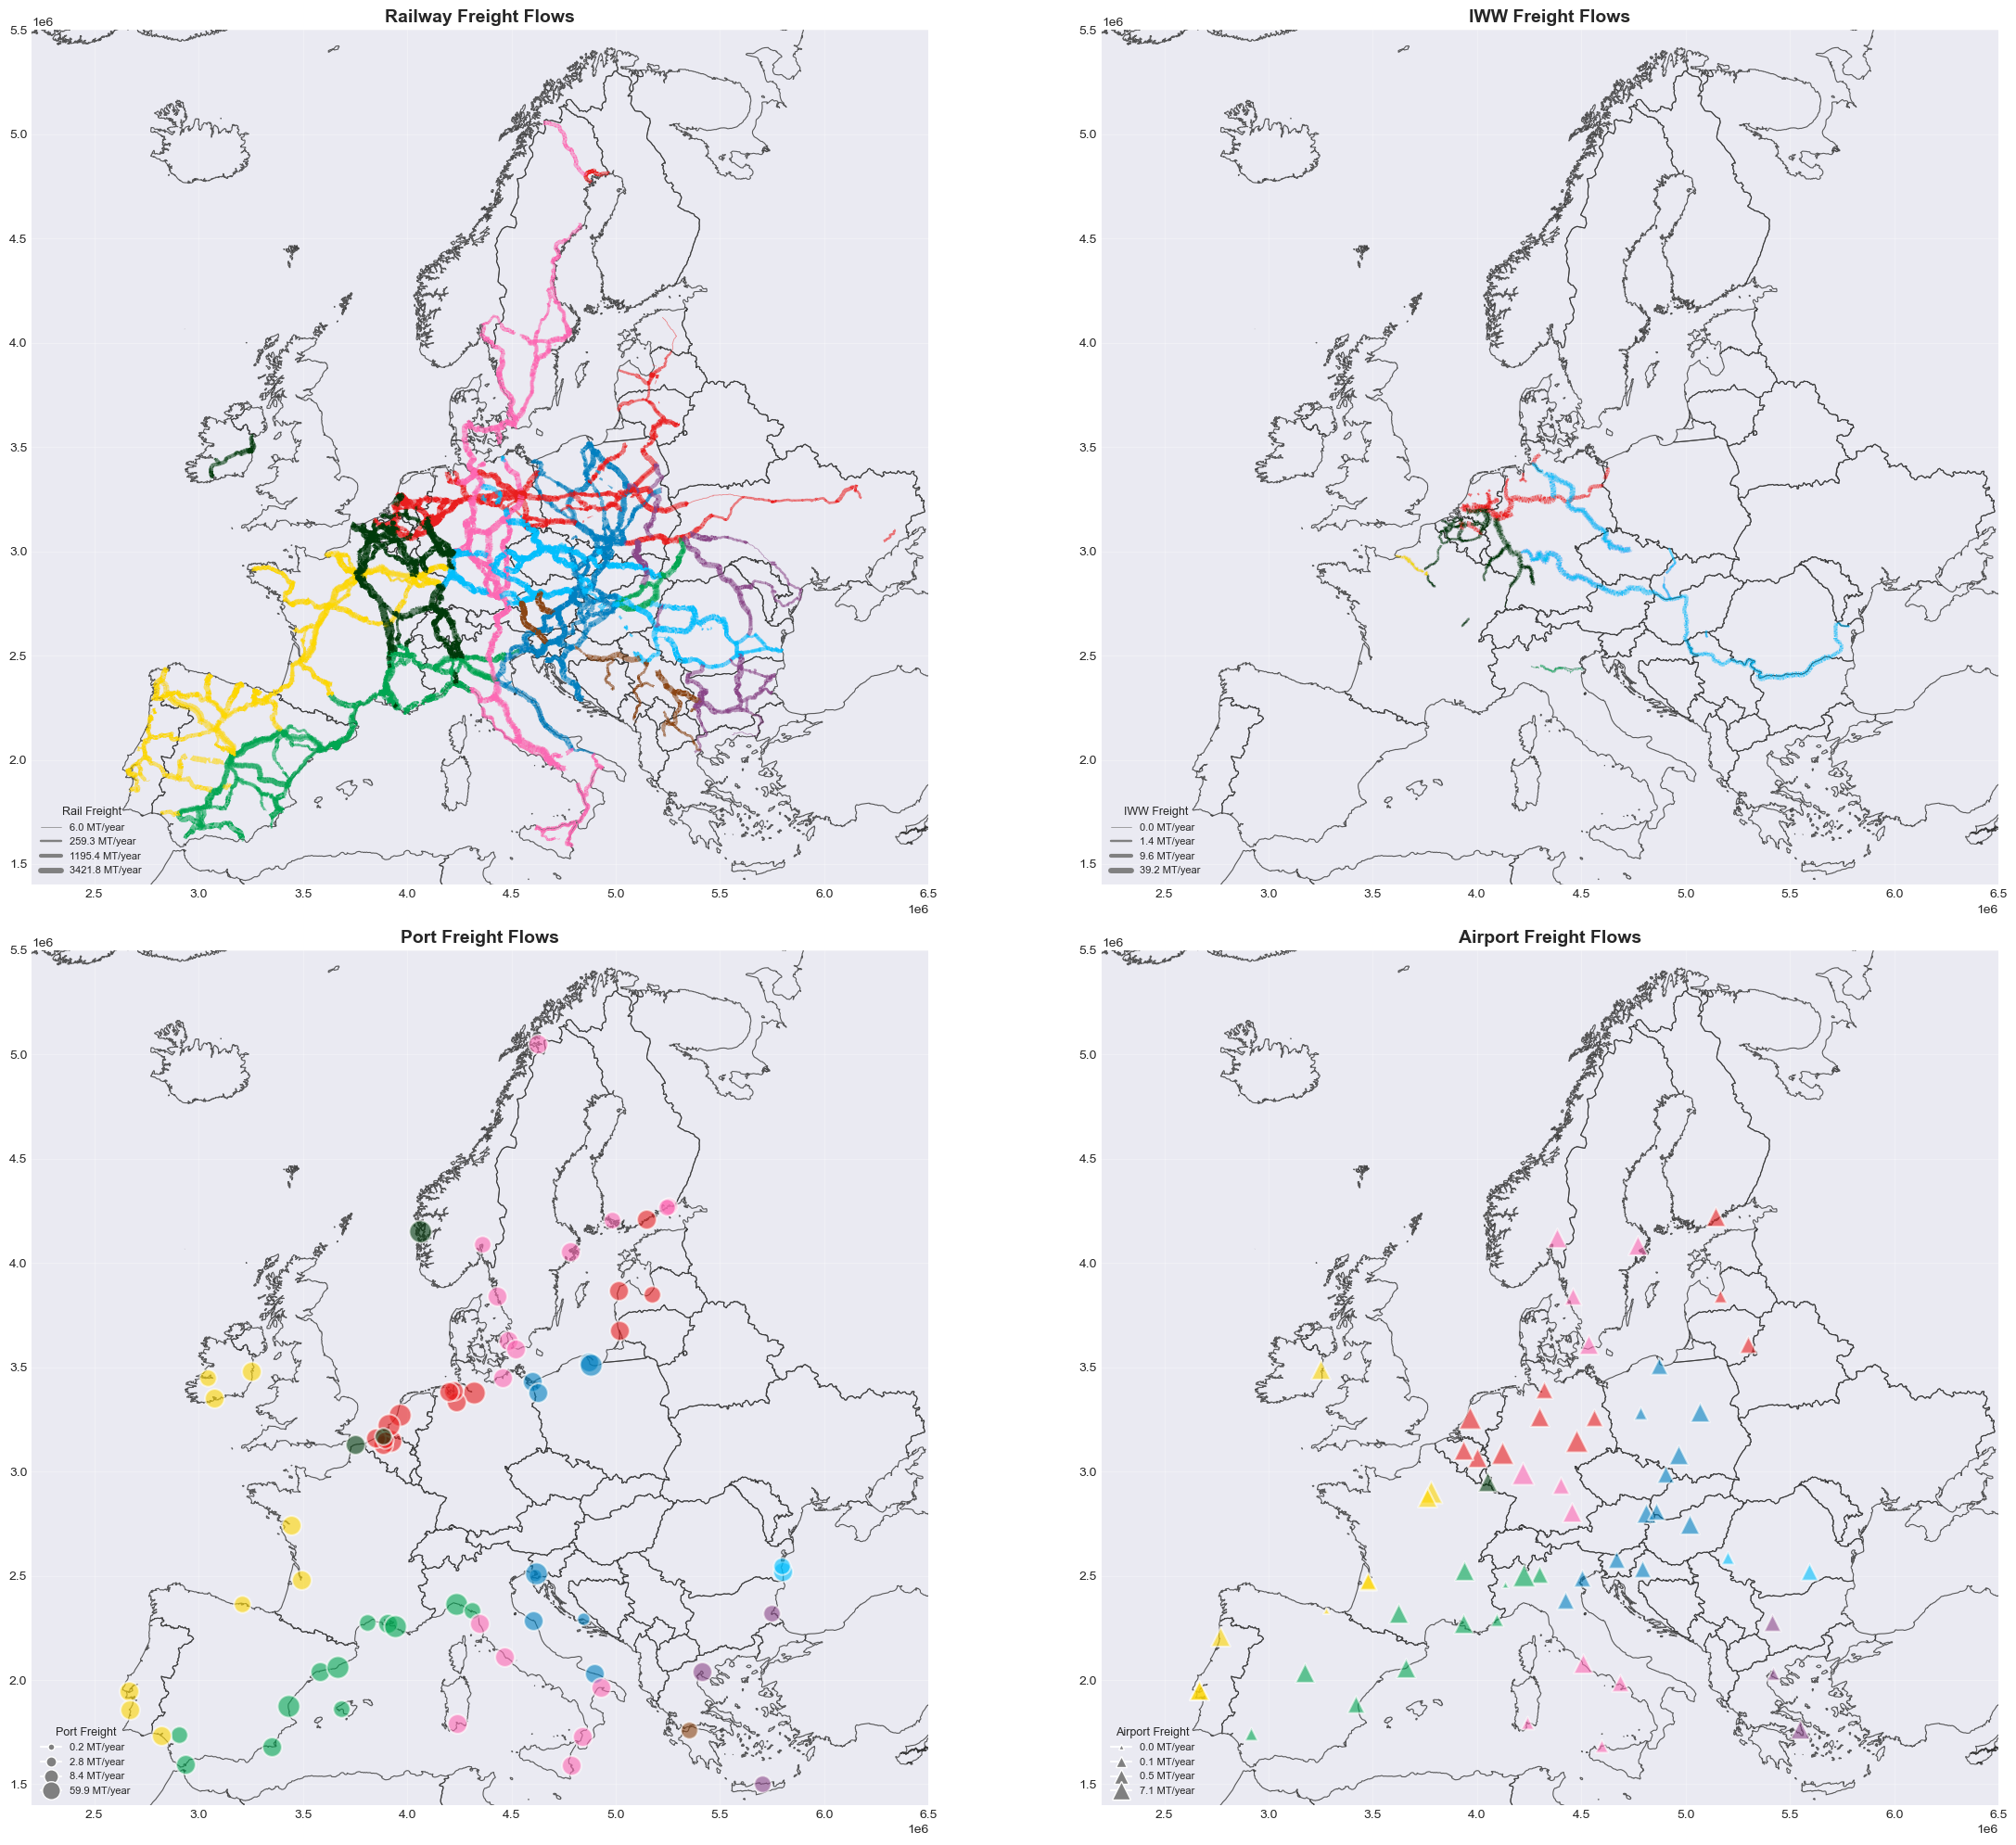

<Figure size 640x480 with 0 Axes>

In [4]:
# Prepare freight flow data
print("Preparing freight flow visualization...\n")

# Aggregate ports by port_code
if 'ports' in infrastructure:
    freight_cols = [col for col in infrastructure['ports'].columns if 'freight' in col.lower() and 'computed' in col.lower()]
    ports_agg = aggregate_by_location(infrastructure['ports'], 'port_code', freight_cols, 'total_freight')
    if ports_agg is not None:
        infrastructure['ports_agg'] = ports_agg

# Aggregate airports
if 'airports' in infrastructure:
    freight_cols = [col for col in infrastructure['airports'].columns if 'freight' in col.lower() and 'computed' in col.lower()]
    if freight_cols:
        infrastructure['airports']['total_freight'] = infrastructure['airports'][freight_cols].fillna(0).sum(axis=1)


fig, axes = plt.subplots(2, 2, figsize=(24, 20))
axes = axes.flatten()

# Railway freight flows
setup_ax(axes[0], europe_countries, infrastructure, 'Railway Freight Flows')
if 'railway_edges' in infrastructure and 'flow_rail_freight' in infrastructure['railway_edges'].columns:
    railway_with_flow = infrastructure['railway_edges'][infrastructure['railway_edges']['flow_rail_freight'] > 0].copy()
    
    if len(railway_with_flow) > 0:
        p05, p35, p65, p95 = railway_with_flow['flow_rail_freight'].quantile([0.05, 0.35, 0.65, 0.95])
        railway_with_flow['linewidth'] = railway_with_flow['flow_rail_freight'].apply(
            lambda x: get_linewidth_freight(x, (p05, p35, p65, p95))
        )
        plot_by_corridor_and_visual_attr(axes[0], railway_with_flow, corridor_colors, 'linewidth')
        
        # Add legend
        line_legend = create_flow_legend((p05, p35, p65, p95), unit='MT/year', is_freight=True)
        axes[0].legend(handles=line_legend, title='Rail Freight', 
                      loc='lower left', fontsize=8, title_fontsize=9)

# IWW freight flows
setup_ax(axes[1], europe_countries, infrastructure, 'IWW Freight Flows')
if 'iww_edges' in infrastructure and 'flow_iww_freight' in infrastructure['iww_edges'].columns:
    iww_with_flow = infrastructure['iww_edges'][infrastructure['iww_edges']['flow_iww_freight'] > 0].copy()
    
    if len(iww_with_flow) > 0:
        p05, p35, p65, p95 = iww_with_flow['flow_iww_freight'].quantile([0.05, 0.35, 0.65, 0.95])
        iww_with_flow['linewidth'] = iww_with_flow['flow_iww_freight'].apply(
            lambda x: get_linewidth_freight(x, (p05, p35, p65, p95))
        )
        plot_by_corridor_and_visual_attr(axes[1], iww_with_flow, corridor_colors, 'linewidth')
        
        line_legend = create_flow_legend((p05, p35, p65, p95), unit='MT/year', is_freight=True)
        axes[1].legend(handles=line_legend, title='IWW Freight', 
                      loc='lower left', fontsize=8, title_fontsize=9)

# Port freight flows
setup_ax(axes[2], europe_countries, infrastructure, 'Port Freight Flows')
if 'ports_agg' in infrastructure:
    ports_with_flow = infrastructure['ports_agg'][infrastructure['ports_agg']['total_freight'] > 0].copy()
    
    if len(ports_with_flow) > 0:
        p05, p35, p65, p95 = ports_with_flow['total_freight'].quantile([0.05, 0.35, 0.65, 0.95])
        ports_with_flow['markersize'] = ports_with_flow['total_freight'].apply(
            lambda x: get_markersize_freight(x, (p05, p35, p65, p95))
        )
        plot_by_corridor_and_visual_attr(axes[2], ports_with_flow, corridor_colors, 'markersize', marker='o')
        
        bubble_legend = create_flow_legend((p05, p35, p65, p95), unit='MT/year', marker='o', is_freight=True)
        axes[2].legend(handles=bubble_legend, title='Port Freight', 
                      loc='lower left', fontsize=8, title_fontsize=9)

# Airport freight flows
setup_ax(axes[3], europe_countries, infrastructure, 'Airport Freight Flows')
if 'airports' in infrastructure and 'total_freight' in infrastructure['airports'].columns:
    airports_with_flow = infrastructure['airports'][infrastructure['airports']['total_freight'] > 0].copy()
    
    if len(airports_with_flow) > 0:
        p05, p35, p65, p95 = airports_with_flow['total_freight'].quantile([0.05, 0.35, 0.65, 0.95])
        airports_with_flow['markersize'] = airports_with_flow['total_freight'].apply(
            lambda x: get_markersize_freight(x, (p05, p35, p65, p95))
        )
        plot_by_corridor_and_visual_attr(axes[3], airports_with_flow, corridor_colors, 'markersize', marker='^')
        
        bubble_legend = create_flow_legend((p05, p35, p65, p95), unit='MT/year', marker='^', is_freight=True)
        axes[3].legend(handles=bubble_legend, title='Airport Freight', 
                      loc='lower left', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig(output_dir / 'freight_flows.png')

## 2.3 Passenger Flows Visualization

These maps identify major passenger movement corridors, which concentrate around metropolitan areas and tourist destinations. Disruptions to high-volume passenger routes have significant socioeconomic impacts on mobility and tourism.

**Visualization method:**
- **Three panels**: Railway, ports (ferries/cruises), and airports
- **Line width** (railway): Proportional to annual passenger volume (millions of trips/year)
- **Bubble size** (ports/airports): Proportional to annual passenger throughput

Passenger infrastructure disruptions can affect both economic activity and quality of life, making these corridors critical for resilience planning.

Preparing passenger flow visualization...



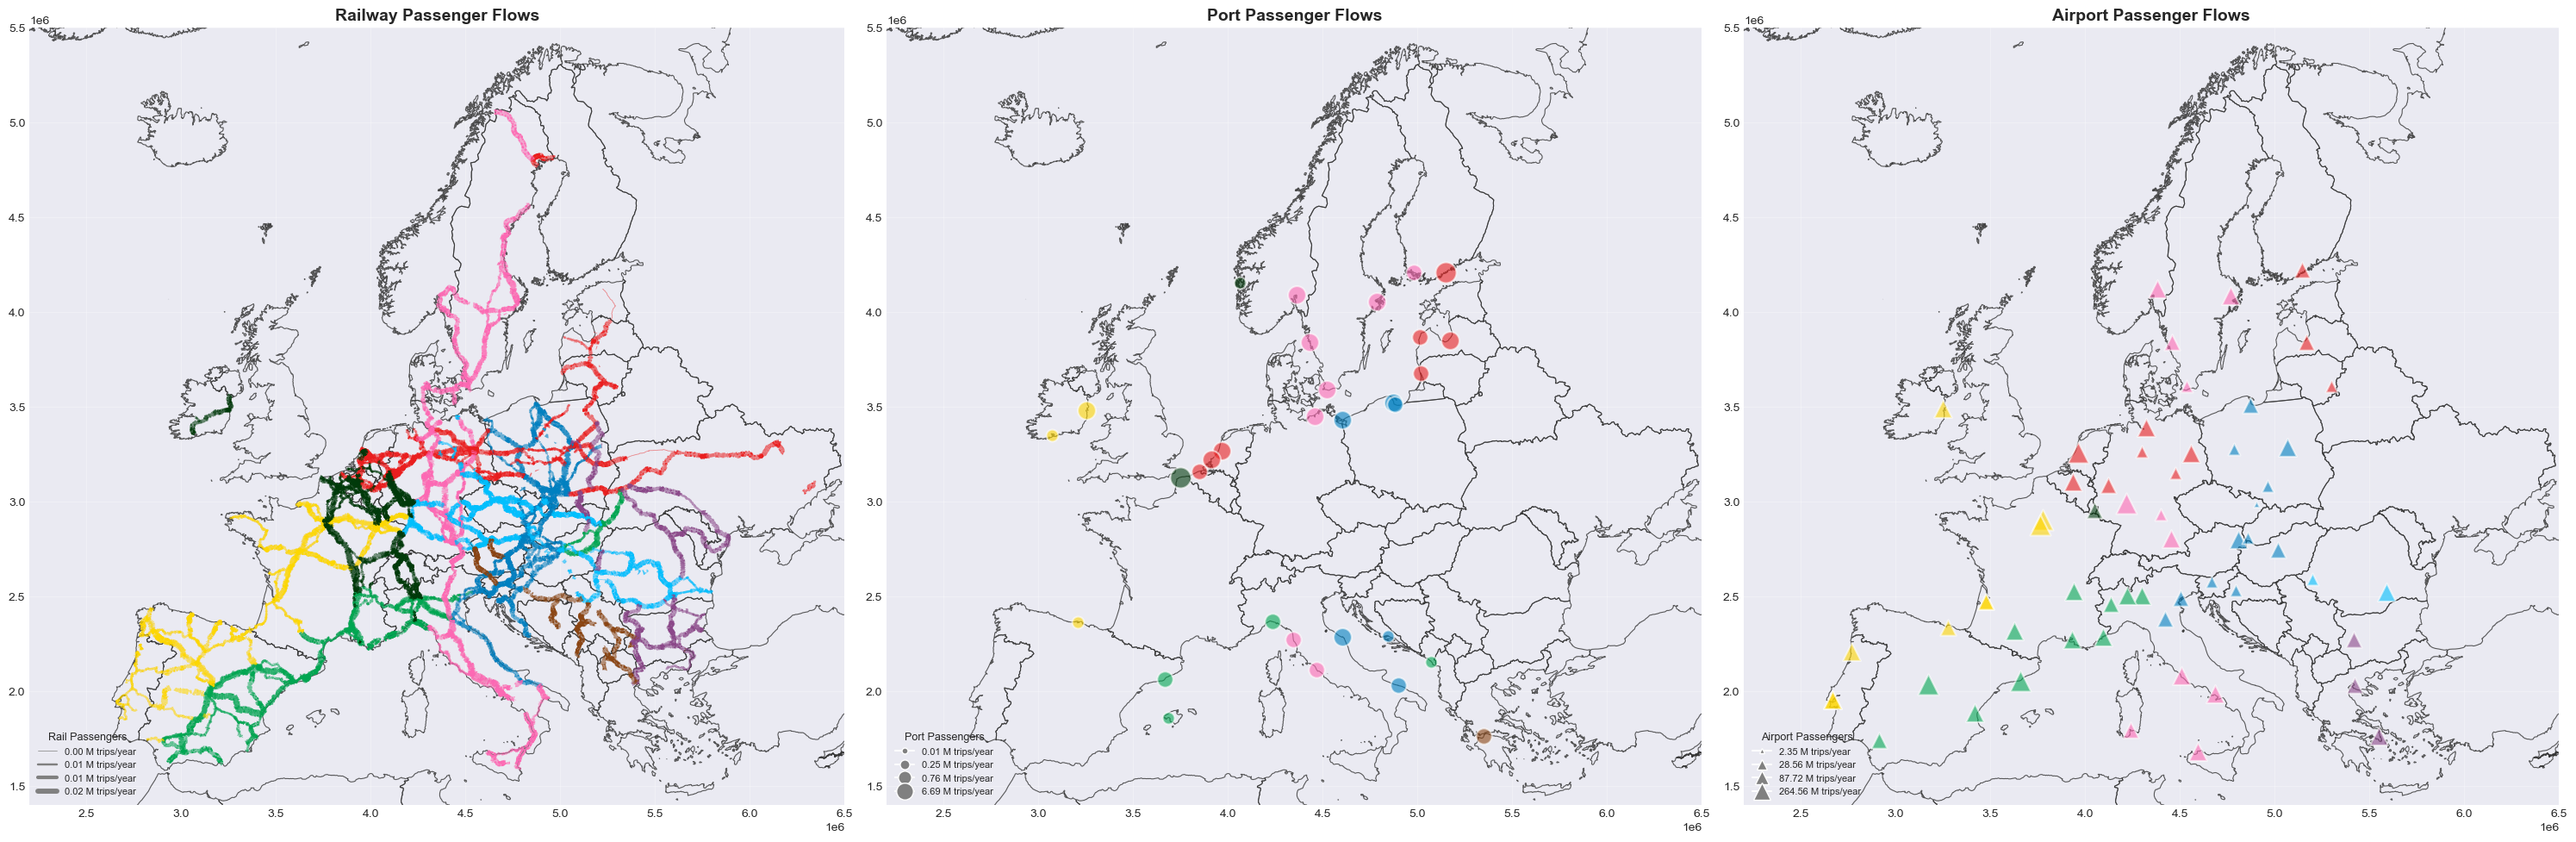

<Figure size 640x480 with 0 Axes>

In [5]:
# Prepare passenger flow data
print("Preparing passenger flow visualization...\n")

# Aggregate ports by port_code for passengers
if 'ports' in infrastructure:
    passenger_cols = [col for col in infrastructure['ports'].columns if 'passenger' in col.lower() and 'computed' in col.lower()]
    ports_pass_agg = aggregate_by_location(infrastructure['ports'], 'port_code', passenger_cols, 'total_passenger')
    if ports_pass_agg is not None:
        infrastructure['ports_pass_agg'] = ports_pass_agg

# Aggregate airports for passengers
if 'airports' in infrastructure:
    passenger_cols = [col for col in infrastructure['airports'].columns if 'passenger' in col.lower() and 'computed' in col.lower()]
    if passenger_cols:
        infrastructure['airports']['total_passenger'] = infrastructure['airports'][passenger_cols].fillna(0).sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(30, 12))

# Railway passenger flows
setup_ax(axes[0], europe_countries, infrastructure, 'Railway Passenger Flows')
if 'railway_edges' in infrastructure and 'flow_rail_passenger' in infrastructure['railway_edges'].columns:
    railway_with_flow = infrastructure['railway_edges'][infrastructure['railway_edges']['flow_rail_passenger'] > 0].copy()
    
    if len(railway_with_flow) > 0:
        p05, p35, p65, p95 = railway_with_flow['flow_rail_passenger'].quantile([0.05, 0.35, 0.65, 0.95])
        railway_with_flow['linewidth'] = railway_with_flow['flow_rail_passenger'].apply(
            lambda x: get_linewidth_passenger(x, (p05, p35, p65, p95))
        )
        plot_by_corridor_and_visual_attr(axes[0], railway_with_flow, corridor_colors, 'linewidth')
        
        line_legend = create_flow_legend((p05, p35, p65, p95), unit='M trips/year', is_freight=False)
        axes[0].legend(handles=line_legend, title='Rail Passengers', 
                      loc='lower left', fontsize=8, title_fontsize=9)

# Port passenger flows
setup_ax(axes[1], europe_countries, infrastructure, 'Port Passenger Flows')
if 'ports_pass_agg' in infrastructure:
    ports_with_flow = infrastructure['ports_pass_agg'][infrastructure['ports_pass_agg']['total_passenger'] > 0].copy()
    
    if len(ports_with_flow) > 0:
        p05, p35, p65, p95 = ports_with_flow['total_passenger'].quantile([0.05, 0.35, 0.65, 0.95])
        ports_with_flow['markersize'] = ports_with_flow['total_passenger'].apply(
            lambda x: get_markersize_passenger(x, (p05, p35, p65, p95))
        )
        plot_by_corridor_and_visual_attr(axes[1], ports_with_flow, corridor_colors, 'markersize', marker='o')
        
        bubble_legend = create_flow_legend((p05, p35, p65, p95), unit='M trips/year', marker='o', is_freight=False)
        axes[1].legend(handles=bubble_legend, title='Port Passengers', 
                      loc='lower left', fontsize=8, title_fontsize=9)

# Airport passenger flows
setup_ax(axes[2], europe_countries, infrastructure, 'Airport Passenger Flows')
if 'airports' in infrastructure and 'total_passenger' in infrastructure['airports'].columns:
    airports_with_flow = infrastructure['airports'][infrastructure['airports']['total_passenger'] > 0].copy()
    
    if len(airports_with_flow) > 0:
        p05, p35, p65, p95 = airports_with_flow['total_passenger'].quantile([0.05, 0.35, 0.65, 0.95])
        airports_with_flow['markersize'] = airports_with_flow['total_passenger'].apply(
            lambda x: get_markersize_passenger(x, (p05, p35, p65, p95))
        )
        plot_by_corridor_and_visual_attr(axes[2], airports_with_flow, corridor_colors, 'markersize', marker='^')
        
        bubble_legend = create_flow_legend((p05, p35, p65, p95), unit='M trips/year', marker='^', is_freight=False)
        axes[2].legend(handles=bubble_legend, title='Airport Passengers', 
                      loc='lower left', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig(output_dir / 'passenger_flows.png')

## 2.4 Industry Locations

This section loads the inputs needed to calculate industry-level disruption costs: the industrial OD matrix, the industry location layer, and the country-sector `kfactor` lookup. These tables are used by the enrichment workflow to translate disrupted freight movements into monetary loss estimates.

It is mostly a data-preparation step. The code checks the available file locations, reads the first matching file for each input, and reports the shapes and columns so later cells can rely on them with less guessing.


In [6]:

# ── Industrial OD (required by enrichment cell) ───────────────────────────────
industrial_od_candidates = [
    country_data_dir_local / 'industries' / 'industrial_OD_threshold_0.25.parquet',
    ]

industrial_od_file = _corridor_utils._pick_existing(industrial_od_candidates)
industrial_od = _safe_read_parquet_any(industrial_od_file) if industrial_od_file.exists() else pd.DataFrame()

# ── Industry locations ─────────────────────────────────────────────────────────
industrial_location_candidates = [
    country_data_dir_local / 'industries' / 'industries_with_closest_ports_airports_euclidean.parquet',
    ]
industrial_locations_file = _corridor_utils._pick_existing(industrial_location_candidates)
industry_locs = _read_parquet_as_gdf(industrial_locations_file) if industrial_locations_file.exists() else gpd.GeoDataFrame()
print(f'\nindustry_locations: {len(industry_locs):,} rows')
print(f'  file: {industrial_locations_file} (exists={industrial_locations_file.exists()})')
print(f'  columns: {industry_locs.columns.tolist()[:12]}')


# ── kfactor lookup (country × sector) ─────────────────────────────────────────
SECTOR_CODE_TO_NAME = {
    'IL': 'intensive livestock',
    'PW': 'paper and wood',
    'FB': 'food and beverage',
    'MI': 'minerals',
    'MT': 'metals',
    'CO': 'commercial',
    'CH': 'chemicals',
}

kfactor_candidates = [
    data_root / 'costs' / 'kfactor.xlsx',
    root / 'data' / 'costs' / 'kfactor.xlsx'
]
kfactor_file = _corridor_utils._pick_existing(kfactor_candidates)
kfactor_raw = pd.read_excel(kfactor_file, sheet_name=0) if kfactor_file.exists() else pd.DataFrame()

if kfactor_raw.empty:
    kfactor_df = pd.DataFrame(columns=['region', 'sector_code', 'sector_name', 'kfactor'])
    kfactor_dict = {}
    print(f'\n[WARN] kfactor lookup not loaded. Checked: {kfactor_candidates}')
else:
    kfactor_df = kfactor_raw.rename(columns={'k_factor': 'kfactor'}).copy()
    if 'product' in kfactor_df.columns:
        kfactor_df['sector_code'] = (
            kfactor_df['product']
            .astype(str)
            .str.replace('CPA_', '', regex=False)
            .str.strip()
            .str.upper()
        )
    else:
        kfactor_df['sector_code'] = ''

    kfactor_df['sector_name'] = (
        kfactor_df['sector_code']
        .map(SECTOR_CODE_TO_NAME)
        .fillna(kfactor_df['sector_code'].str.lower())
        .astype(str)
        .str.strip()
        .str.lower()
    )

    if 'region' not in kfactor_df.columns:
        kfactor_df['region'] = ''

    kfactor_df['kfactor'] = pd.to_numeric(kfactor_df['kfactor'], errors='coerce')
    kfactor_df = kfactor_df.dropna(subset=['kfactor'])
    kfactor_df = kfactor_df[kfactor_df['sector_name'].ne('')].copy()
    kfactor_dict = kfactor_df.groupby('sector_name')['kfactor'].mean().to_dict()


globals().update({
    'SECTOR_CODE_TO_NAME': SECTOR_CODE_TO_NAME,
    'kfactor_file': kfactor_file,
    'kfactor_raw': kfactor_raw,
    'kfactor_df': kfactor_df,
    'kfactor_dict': kfactor_dict,
})


industry_locations: 46,186 rows
  file: \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\inputs\country_data\Corridors_NUTS2\rhine-alpine\industries\industries_with_closest_ports_airports_euclidean.parquet (exists=True)
  columns: ['id', 'nuts2', 'eprtr_sectors', 'eea_activities', 'area', 'area_nuts2', 'longitude', 'latitude', 'closest_port', 'closest_airport', 'closest_iww_port', 'closest_node']


## Hazard Exposure Quantification

This section visualizes the spatial distribution of climate hazards across Europe. These maps serve as the reference layer for identifying which infrastructure assets face exposure to flooding and windstorms.

**Maps shown:**
- **Flood depth (RP100)**: Inundation depth in meters for 100-year return period river flood events
- **Wind speed (RP100)**: Maximum gust speeds in m/s for 100-year return period windstorm events

**Return period (RP) interpretation:** RP100 = expected once every 100 years on average (1% annual exceedance probability)

Overlaying infrastructure on these hazard maps enables quantification of asset exposure and direct climate risk assessment.

Loading 100-year return period hazard maps...
Processing flood raster...
Processing wind raster...


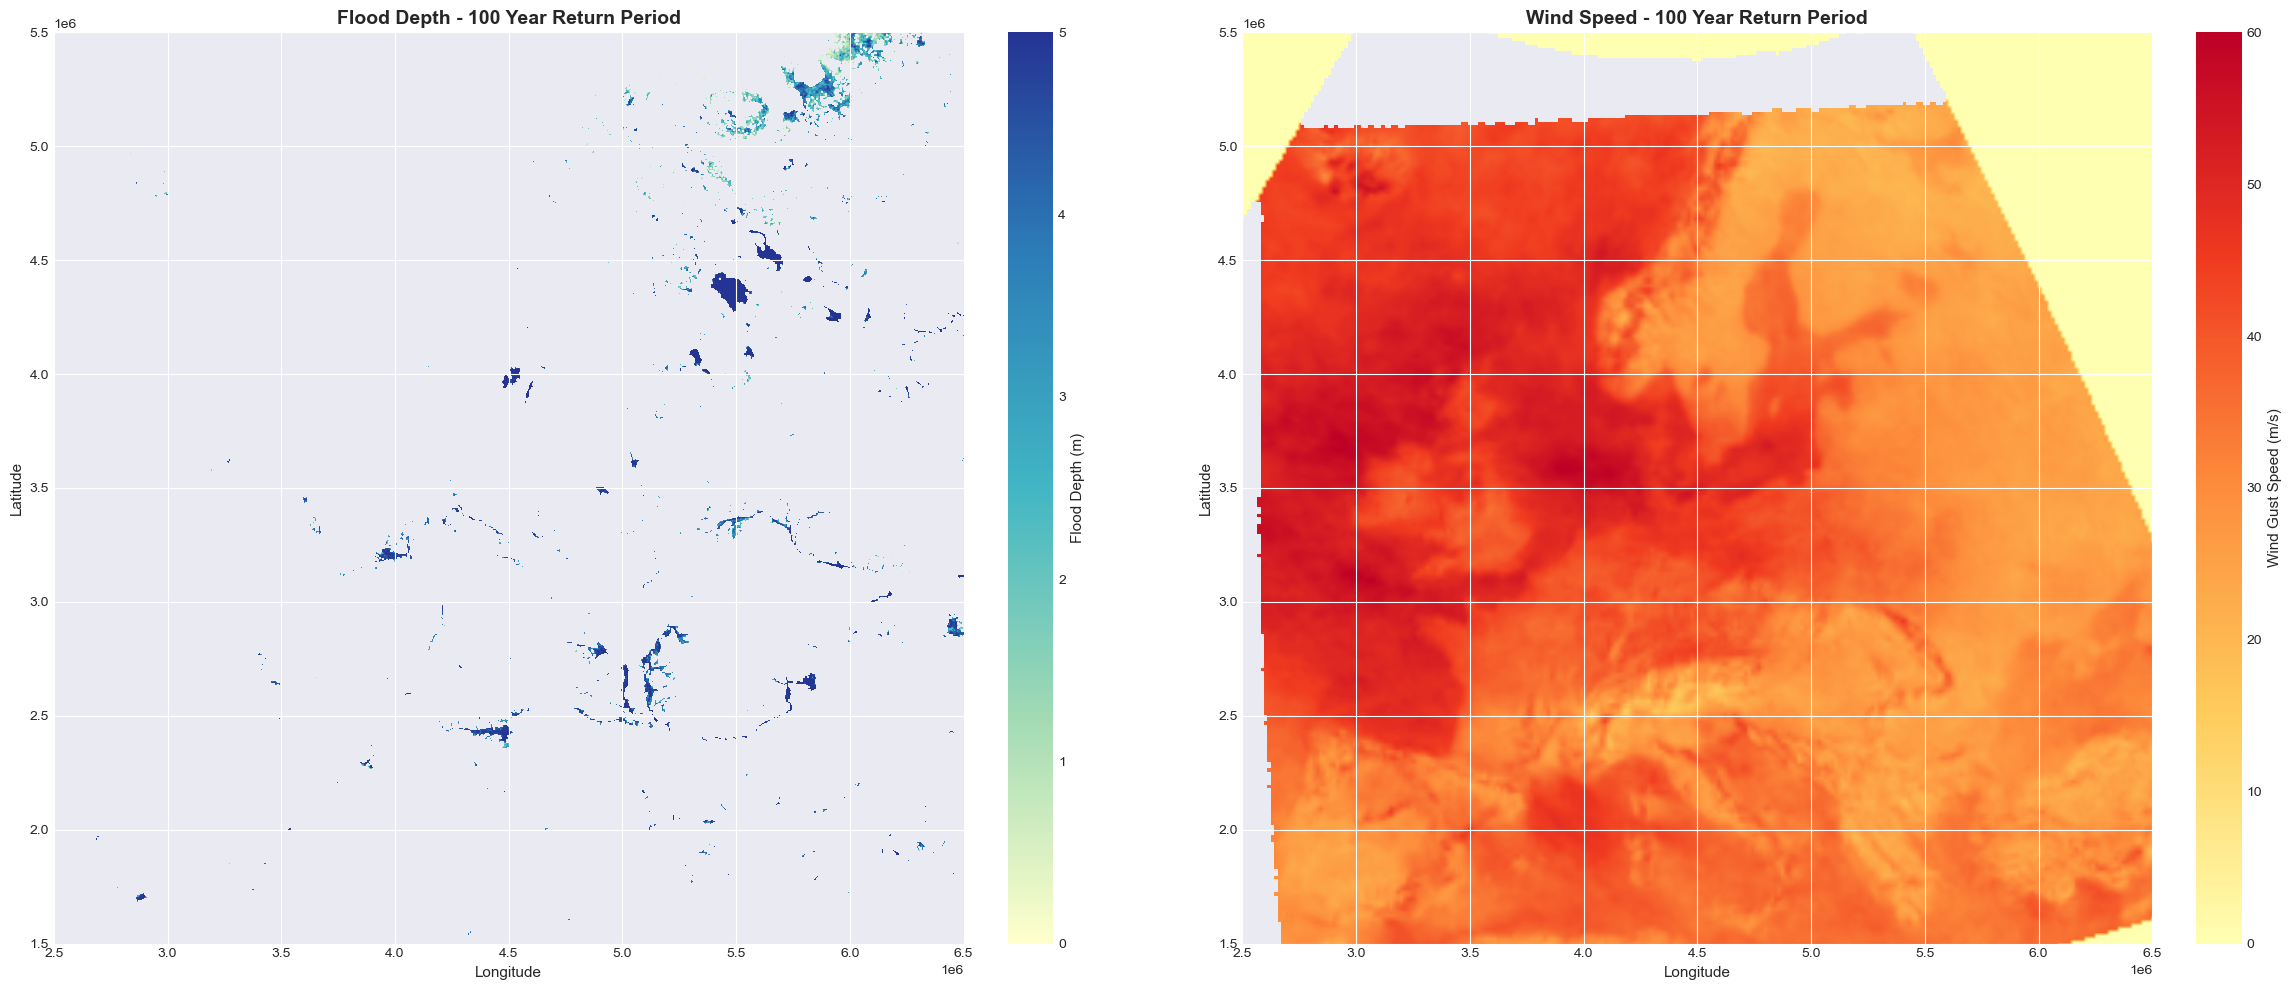

In [7]:
# All imports consolidated in Cell 3; rasterio and colors already loaded.
# Get Europe mask for clipping
from shapely.geometry import box
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
# Paths to hazard maps (use hazard_dir defined in Cell 4)
flood_map_path = hazard_dir / "River_flood" / "RP100_europe.tif"
wind_map_path = hazard_dir / "Windstorms" / "RP100_europe.tif"

print("Loading 100-year return period hazard maps...")

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Load and reproject rasters using utility function
flood_raster = reproject_raster_to_3035(flood_map_path)
wind_raster = reproject_raster_to_3035(wind_map_path)

# Create bounding box from infrastructure
if 'railway_edges' in infrastructure:
    infra_bounds = infrastructure['railway_edges'].total_bounds
    bbox = gpd.GeoDataFrame(
        {'geometry': [box(*infra_bounds)]},
        crs='EPSG:3035'
    )

# Plot flood depth map
if flood_raster is not None:
    print("Processing flood raster...")

    flood_cmap = colors.LinearSegmentedColormap.from_list(
        'flood', ['#ffffcc', '#a1dab4', '#41b6c4', '#2c7fb8', '#253494']
    )

    show(flood_raster, ax=axes[0], cmap=flood_cmap, interpolation='bilinear')

    if europe_countries is not None:
        europe_countries.boundary.plot(ax=axes[0], color='black', linewidth=0.5, alpha=0.6)

    axes[0].set_title('Flood Depth - 100 Year Return Period', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Longitude', fontsize=11)
    axes[0].set_ylabel('Latitude', fontsize=11)
    axes[0].set_xlim(2_500_000, 6_500_000)
    axes[0].set_ylim(1_500_000, 5_500_000)

    sm1 = ScalarMappable(cmap=flood_cmap, norm=Normalize(vmin=0, vmax=5))
    sm1.set_array([])
    cbar1 = plt.colorbar(sm1, ax=axes[0], fraction=0.046, pad=0.04)
    cbar1.set_label('Flood Depth (m)', fontsize=11)

# Plot wind speed map
if wind_raster is not None:
    print("Processing wind raster...")

    wind_cmap = colors.LinearSegmentedColormap.from_list(
        'wind', ['#ffffb2', '#fecc5c', '#fd8d3c', '#f03b20', '#bd0026']
    )

    show(wind_raster, ax=axes[1], cmap=wind_cmap, interpolation='bilinear')

    if europe_countries is not None:
        europe_countries.boundary.plot(ax=axes[1], color='black', linewidth=0.5, alpha=0.6)

    axes[1].set_title('Wind Speed - 100 Year Return Period', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Longitude', fontsize=11)
    axes[1].set_ylabel('Latitude', fontsize=11)
    axes[1].set_xlim(2_500_000, 6_500_000)
    axes[1].set_ylim(1_500_000, 5_500_000)

    sm2 = ScalarMappable(cmap=wind_cmap, norm=Normalize(vmin=0, vmax=60))
    sm2.set_array([])
    cbar2 = plt.colorbar(sm2, ax=axes[1], fraction=0.046, pad=0.04)
    cbar2.set_label('Wind Gust Speed (m/s)', fontsize=11)

plt.tight_layout()
plt.show()

# 3. Direct Damages: River flood assessment of freight railway system for the North Sea - Rhine - Mediterranean corridor

The North Sea–Rhine–Mediterranean (NSRM) corridor is one of nine Trans-European Transport Network (TEN-T) corridors that act as primary arteries moving goods and people to their destinations. Stretching across eight countries, the NSRM comprises roughly 12,150 km of rail, 5,000 km of road, and 5,030 km of inland waterways. The network is a vital economic artery and handles over 15% of Europe's road freight, more than 44% of rail freight, and nearly 90% of inland waterway freight. Major gateways like Rotterdam, Antwerp, and Amsterdam serve as the heart of trade logistics connecting European industry to global trade. Given the breadth and complexity of the disruption and indirect losses analysis, we now focus on presenting the results for this main corridor. The results can be replicated to any of the other TEN-T corridors.

This section quantifies the direct economic impacts of river flooding on railway infrastructure under both current and future climate conditions.

**Analysis scope:**
1. **Exposure quantification**: Length of railway segments with flood exposure at multiple return periods
2. **Damage assessment**: Direct economic loss based on flood depth and infrastructure replacement value
3. **Risk metrics**: Current conditions and climate change scenarios (1.5°C – 4.0°C warming)
4. **Temporal evolution**: How flood frequency and associated losses change under different warming trajectories

Loading railway flood risk data from the Rhine-Alpine hazard parquet...

Source: \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\inputs\climate_hazards\Corridors\rhine-alpine\TENT_rail_river.parquet
Merged railway edges with risk data: 739,849 rows


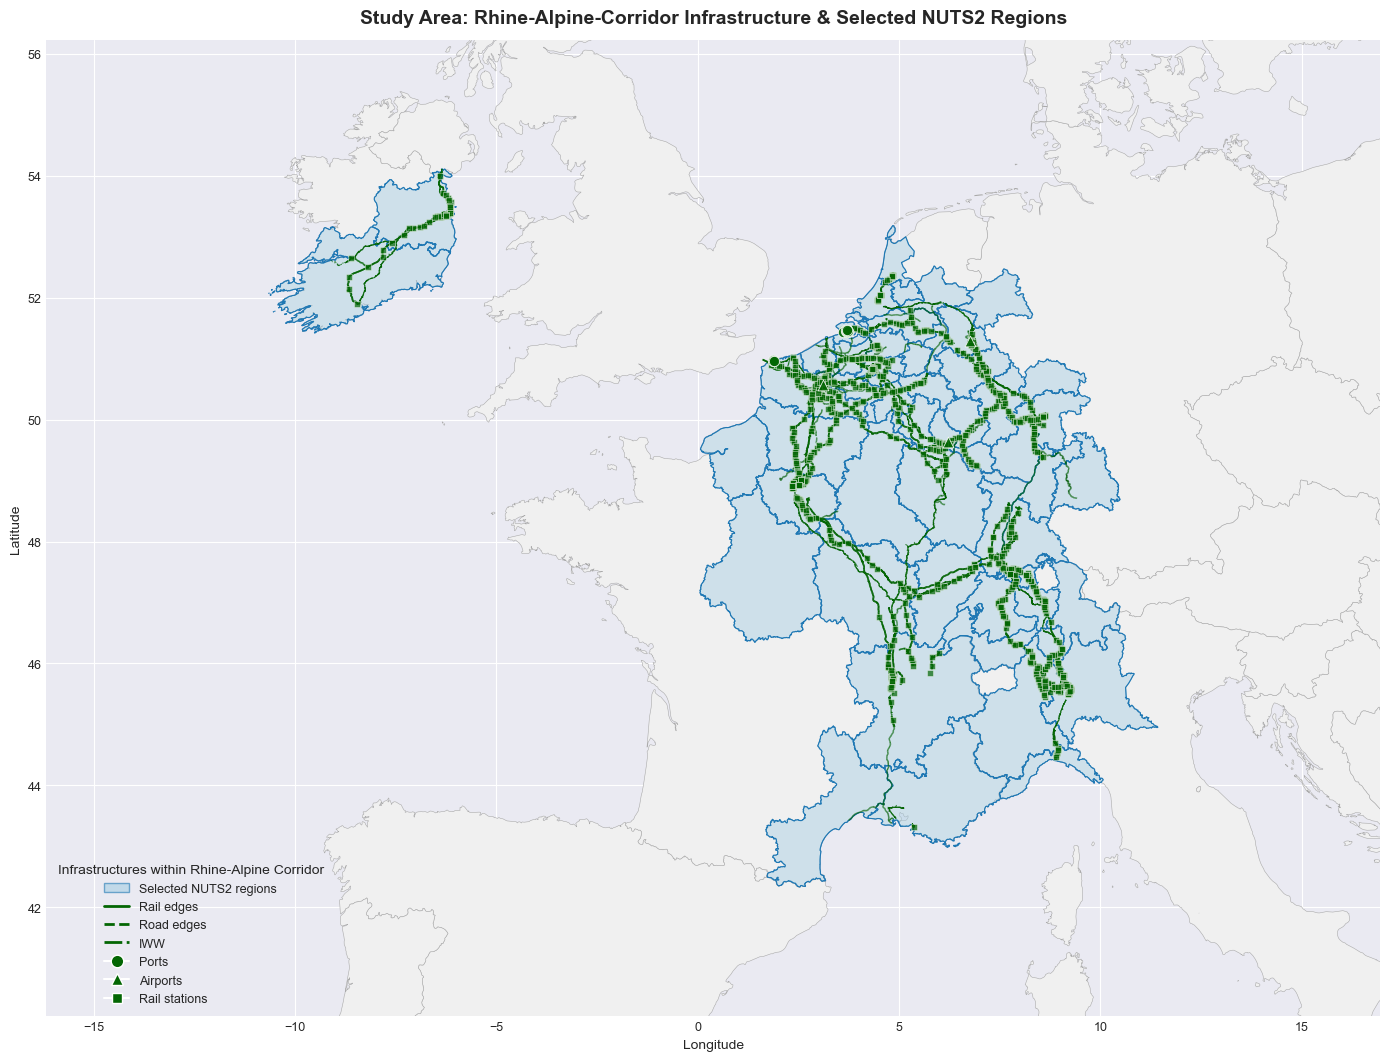

In [14]:
# Load railway risk data from the Rhine-Alpine hazard parquet
risk_dir = code_dir.parent / "inputs" / "climate_hazards" / "Corridors" / "rhine-alpine"
rail_risk_path = risk_dir / "TENT_rail_river.parquet"

print("Loading railway flood risk data from the Rhine-Alpine hazard parquet...\n")
print(f"Source: {rail_risk_path}")

# Load the parquet and inspect its schema first
rail_risk = pd.read_parquet(rail_risk_path)

# Map the parquet columns onto the names expected by the plotting cells
if "EAD_mid_river_current" in rail_risk.columns and "mean_damage_100" not in rail_risk.columns:
    rail_risk["mean_damage_100"] = rail_risk["EAD_mid_river_current"]
if "exposure_length_river_RP100" in rail_risk.columns and "exposure_100" not in rail_risk.columns:
    rail_risk["exposure_100"] = rail_risk["exposure_length_river_RP100"]
if "EAD_mid_river_current" in rail_risk.columns and "EAD" not in rail_risk.columns:
    rail_risk["EAD"] = rail_risk["EAD_mid_river_current"]
if "vuln_ratio_river_RP100" in rail_risk.columns and "pct_damage_100" not in rail_risk.columns:
    rail_risk["pct_damage_100"] = rail_risk["vuln_ratio_river_RP100"] * 100.0

# Add simple scenario placeholders from the same parquet file so later cells can run
scenario_sources = {
    "1.5C": "EAD_mid_river_2050_SSP245",
    "2.0C": "EAD_mid_river_2050_SSP585",
    "3.0C": "EAD_mid_river_2100_SSP245",
    "4.0C": "EAD_mid_river_2100_SSP585",
}
for scenario, source in scenario_sources.items():
    if source in rail_risk.columns:
        rail_risk[f"damage_cc_{scenario}"] = rail_risk[source]
        rail_risk[f"EAD_{scenario}"] = rail_risk[source]
        rail_risk[f"adjusted_rp_100_{scenario}"] = 100.0

# Merge the parquet-based risk table onto the railway geometry
if "railway_edges" in infrastructure:
    railway_with_risk = infrastructure["railway_edges"].copy()
    merge_cols = ["id"] + [c for c in rail_risk.columns if c not in railway_with_risk.columns and c != "geometry"]
    railway_with_risk = railway_with_risk.merge(
        rail_risk[merge_cols],
        on="id",
        how="left",
    )
    print(f"Merged railway edges with risk data: {len(railway_with_risk):,} rows")
else:
    print("\nWarning: Railway edges not loaded in infrastructure data")
    railway_with_risk = gpd.GeoDataFrame()

# Ensure the plotting columns are numeric
for col in ["mean_damage_100", "exposure_100", "EAD", "pct_damage_100"]:
    if col in railway_with_risk.columns:
        railway_with_risk[col] = pd.to_numeric(railway_with_risk[col], errors="coerce").fillna(0.0)

railway_exposed = (
    railway_with_risk[railway_with_risk["exposure_100"] > 0].copy()
    if "exposure_100" in railway_with_risk.columns
    else railway_with_risk.copy()
)

# ── Study area overview: Europe + L-corridor infrastructure + selected NUTS2 ──
_INFRA_GREEN = "#036603"

fig_ov, ax_ov = plt.subplots(1, 1, figsize=(14, 16))

# 1) Europe background
if isinstance(europe_countries, gpd.GeoDataFrame) and not europe_countries.empty:
    _ec = europe_countries.to_crs("EPSG:4326") if europe_countries.crs and str(europe_countries.crs) != "EPSG:4326" else europe_countries
    _ec.plot(ax=ax_ov, color="#f0f0f0", edgecolor="#aaaaaa", linewidth=0.4, zorder=1)

# 2) Selected NUTS2 highlighted
if isinstance(nuts2, gpd.GeoDataFrame) and not nuts2.empty:
    _nuts2_plot = nuts2.to_crs("EPSG:4326") if nuts2.crs and str(nuts2.crs) != "EPSG:4326" else nuts2
    _nuts2_plot.plot(
        ax=ax_ov,
        color="#a6cee3",
        edgecolor="#1f78b4",
        linewidth=0.7,
        alpha=0.45,
        zorder=2,
    )
    _nuts2_plot.boundary.plot(ax=ax_ov, color="#1f78b4", linewidth=0.8, zorder=3)
else:
    _nuts2_plot = None


def _to_4326(gdf):
    if gdf is None or (isinstance(gdf, gpd.GeoDataFrame) and gdf.empty):
        return gdf
    if gdf.crs is None or str(gdf.crs) == "EPSG:4326":
        return gdf
    try:
        return gdf.to_crs("EPSG:4326")
    except Exception:
        return gdf


def _filter_has_L_in_corridor(gdf):
    """Keep rows where CORRIDOR(S) includes token L (alone or with other letters)."""
    if gdf is None or (isinstance(gdf, gpd.GeoDataFrame) and gdf.empty):
        return gdf

    corridor_cols = [c for c in ("CORRIDOR", "CORRIDORS", "corridor", "corridors") if c in gdf.columns]
    if not corridor_cols:
        return gpd.GeoDataFrame(columns=gdf.columns, crs=gdf.crs)

    # Accept forms like: L, A|L, L|B, A;L, A,L
    token_pat = r"(^|[|,;\s])L($|[|,;\s])"

    mask = pd.Series(False, index=gdf.index)
    for col in corridor_cols:
        ser = (
            gdf[col]
            .astype(str)
            .str.upper()
            .str.replace("/", "|", regex=False)
            .str.replace("-", "|", regex=False)
        )
        mask = mask | ser.str.contains(token_pat, regex=True, na=False)

    return gdf[mask].copy()


# 3) Infrastructure filtered to L in CORRIDOR(S), all green
_rail = _to_4326(_filter_has_L_in_corridor(globals().get("rail_edges")))
_road = _to_4326(_filter_has_L_in_corridor(globals().get("road_edges")))
_iww = _to_4326(_filter_has_L_in_corridor(globals().get("iww_edges")))
_ports = _to_4326(_filter_has_L_in_corridor(globals().get("ports")))
_air = _to_4326(_filter_has_L_in_corridor(globals().get("airports")))
_rail_st = _to_4326(_filter_has_L_in_corridor(globals().get("rail_stations")))

_legend_handles = []

if _rail is not None and not _rail.empty:
    _rail.plot(ax=ax_ov, color=_INFRA_GREEN, linewidth=1.2, alpha=0.85, zorder=5)
    _legend_handles.append(Line2D([0], [0], color=_INFRA_GREEN, lw=2, label="Rail edges"))

if _road is not None and not _road.empty:
    _road.plot(ax=ax_ov, color=_INFRA_GREEN, linewidth=0.8, alpha=0.7, zorder=4, linestyle="--")
    _legend_handles.append(Line2D([0], [0], color=_INFRA_GREEN, lw=2, ls="--", label="Road edges"))

if _iww is not None and not _iww.empty:
    _iww.plot(ax=ax_ov, color=_INFRA_GREEN, linewidth=1.0, alpha=0.8, zorder=4, linestyle="-.")
    _legend_handles.append(Line2D([0], [0], color=_INFRA_GREEN, lw=2, ls="-.", label="IWW"))

if _ports is not None and not _ports.empty:
    _ports.plot(ax=ax_ov, color=_INFRA_GREEN, markersize=55, marker="o", alpha=0.9, edgecolor="white", linewidth=0.6, zorder=7)
    _legend_handles.append(Line2D([0], [0], marker="o", color="w", markerfacecolor=_INFRA_GREEN, markersize=9, label="Ports", markeredgecolor="white"))

if _air is not None and not _air.empty:
    _air.plot(ax=ax_ov, color=_INFRA_GREEN, markersize=60, marker="^", alpha=0.9, edgecolor="white", linewidth=0.6, zorder=7)
    _legend_handles.append(Line2D([0], [0], marker="^", color="w", markerfacecolor=_INFRA_GREEN, markersize=9, label="Airports", markeredgecolor="white"))

if _rail_st is not None and not _rail_st.empty:
    _rail_st.plot(ax=ax_ov, color=_INFRA_GREEN, markersize=18, marker="s", alpha=0.7, edgecolor="white", linewidth=0.4, zorder=6)
    _legend_handles.append(Line2D([0], [0], marker="s", color="w", markerfacecolor=_INFRA_GREEN, markersize=7, label="Rail stations", markeredgecolor="white"))

from matplotlib.patches import Patch
_legend_handles.insert(0, Patch(facecolor="#a6cee3", edgecolor="#1f78b4", alpha=0.6, label="Selected NUTS2 regions"))

# 4) Extent
if _nuts2_plot is not None and not _nuts2_plot.empty:
    _bb = _nuts2_plot.total_bounds
    _pad_x = (_bb[2] - _bb[0]) * 0.25
    _pad_y = (_bb[3] - _bb[1]) * 0.18
    ax_ov.set_xlim(_bb[0] - _pad_x, _bb[2] + _pad_x)
    ax_ov.set_ylim(_bb[1] - _pad_y, _bb[3] + _pad_y)
else:
    ax_ov.set_xlim(-2, 20)
    ax_ov.set_ylim(42, 57)

ax_ov.legend(
    handles=_legend_handles,
    loc="lower left",
    fontsize=9,
    title="Infrastructures within Rhine-Alpine Corridor",
    title_fontsize=10,
    framealpha=0.9,
)
ax_ov.set_title("Study Area: Rhine-Alpine-Corridor Infrastructure & Selected NUTS2 Regions", fontsize=14, fontweight="bold", pad=12)
ax_ov.set_xlabel("Longitude", fontsize=10)
ax_ov.set_ylabel("Latitude", fontsize=10)
ax_ov.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

## 3.1 Current Climate Risk

These four maps show complementary views of current-day railway flood risk under a RP100 (100-year) event scenario:

1. **Exposed Length**: Meters of track with flood hazard exposure (identifies vulnerable segments)
2. **Damage Percentage**: Proportion of asset value at risk (capped at 100% for visualization)
3. **Direct Damage (log scale)**: Absolute repair/replacement cost in euros (identifies high-value loss hotspots)
4. **Expected Annual Damage (EAD, log scale)**: Annualized loss integrating all return periods (planning-ready metric)


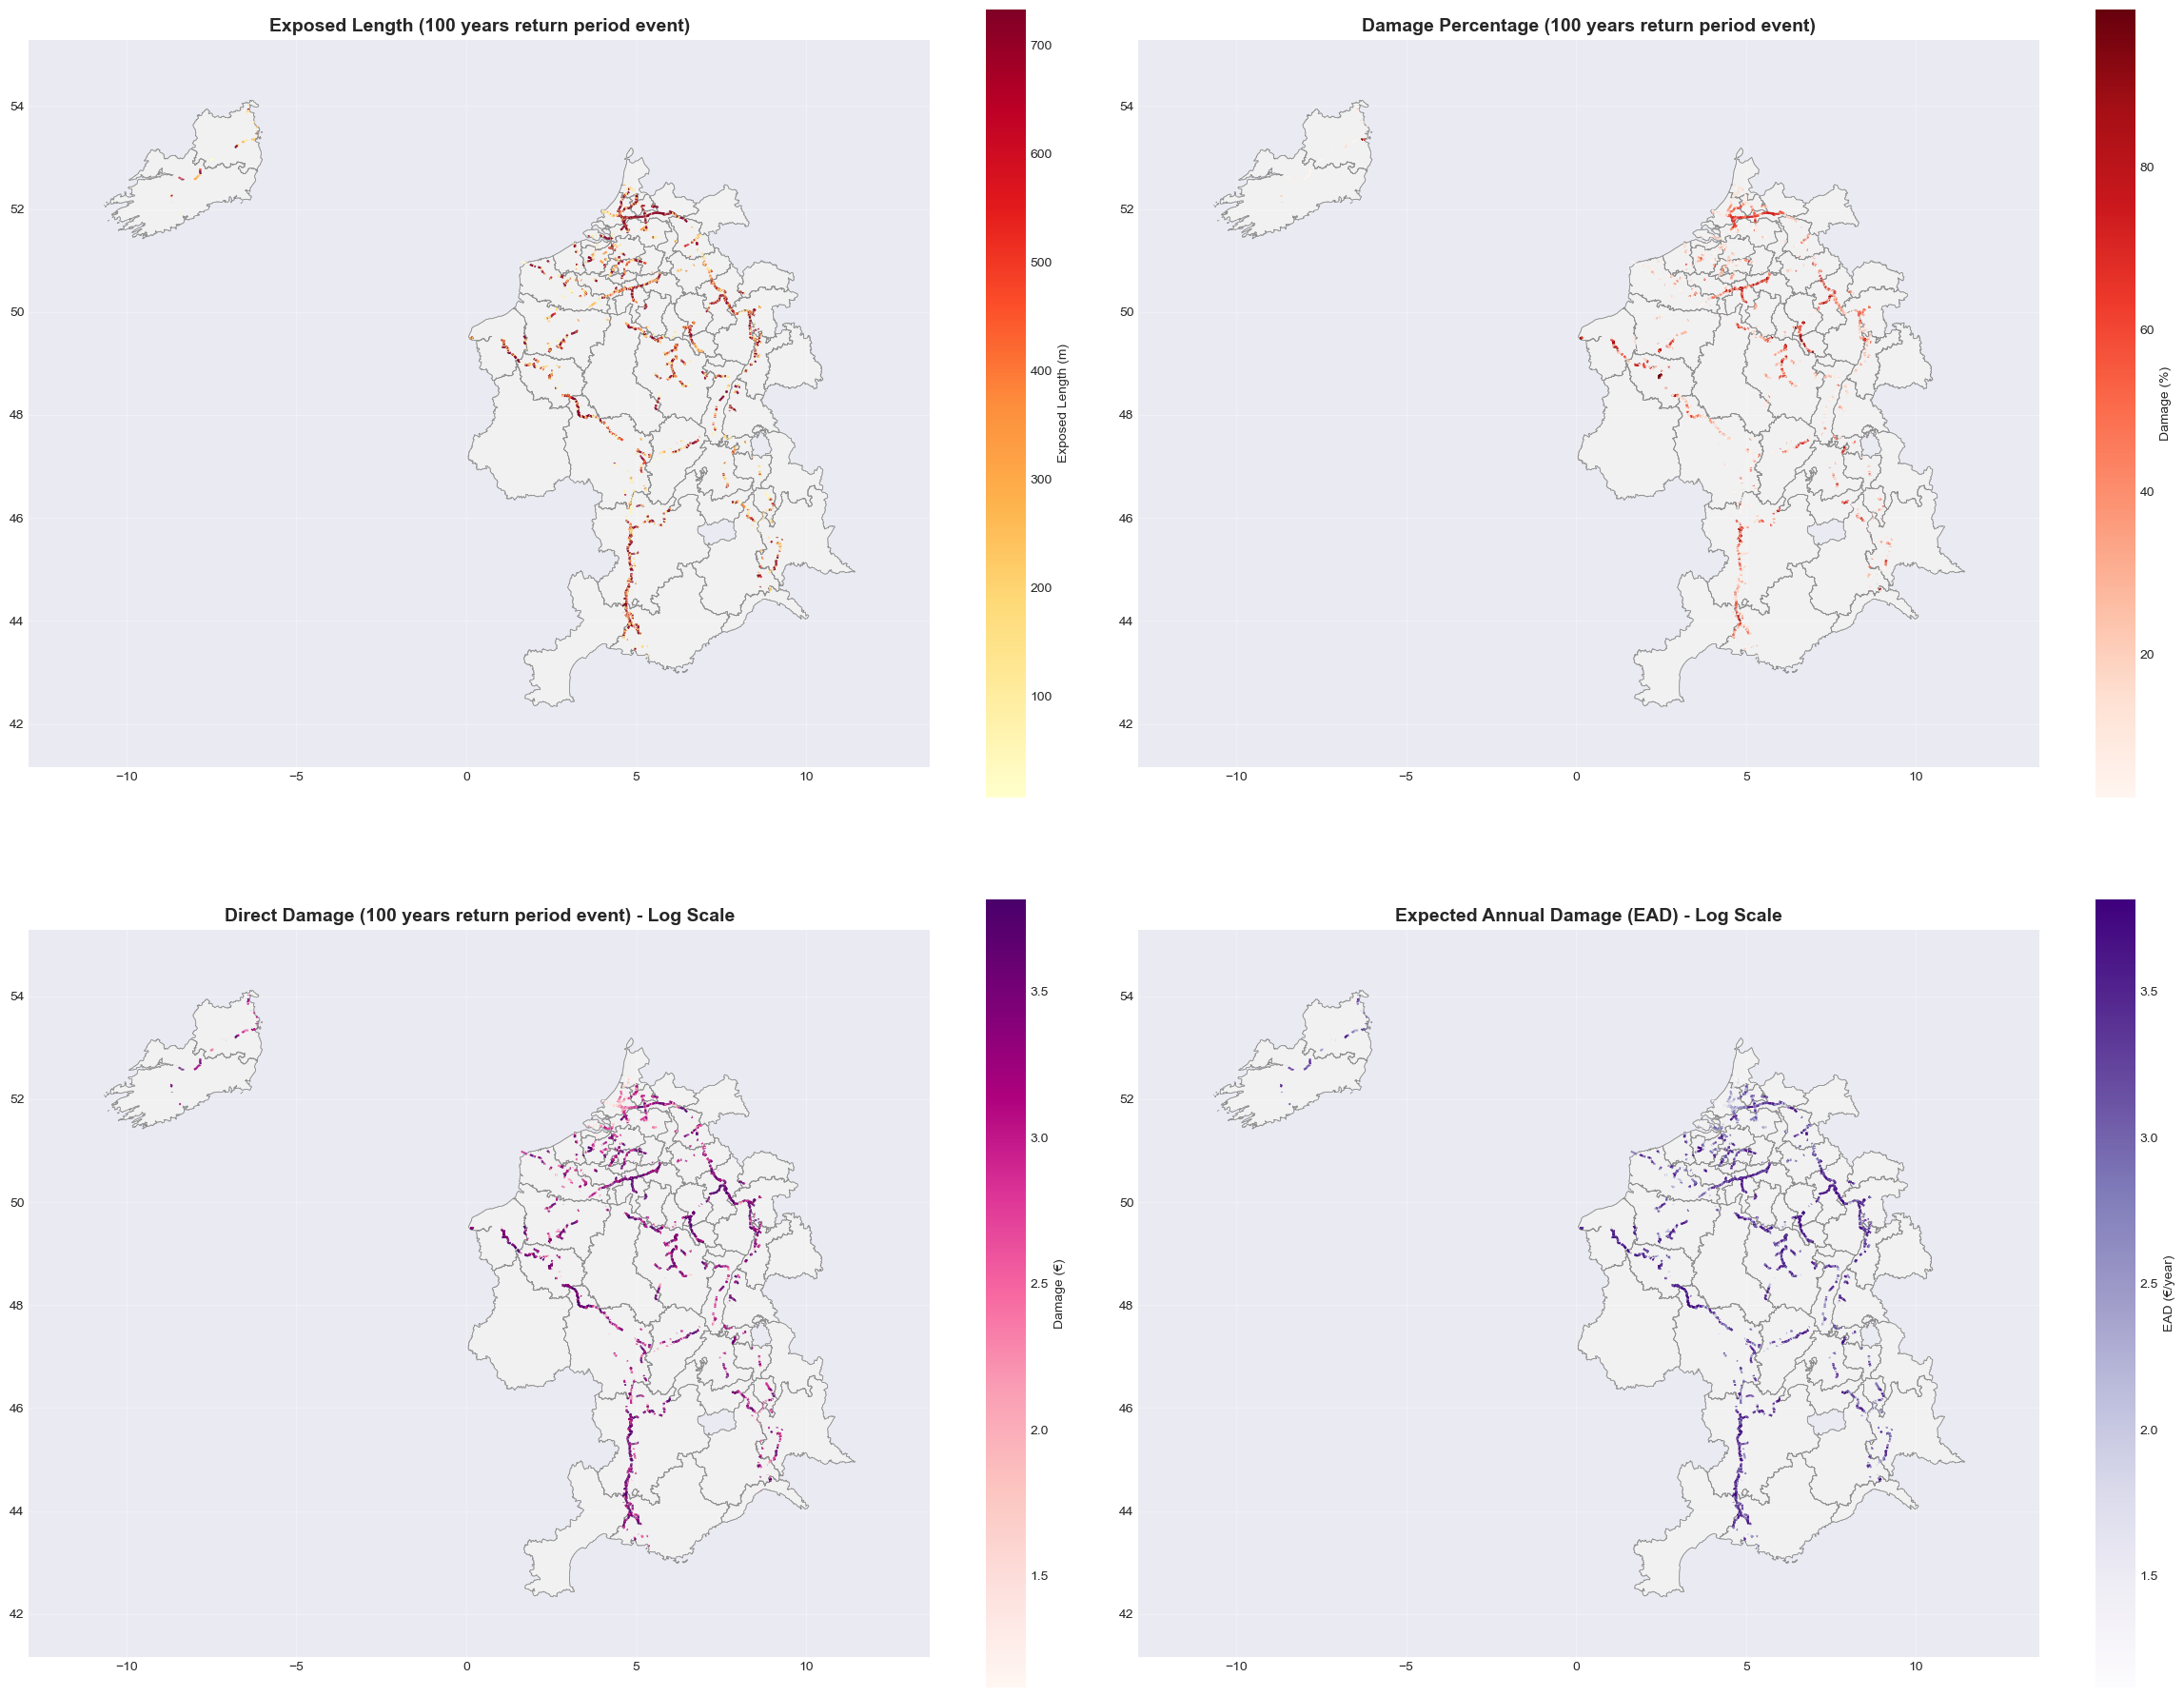

<Figure size 640x480 with 0 Axes>

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(24, 20))
axes = axes.flatten()


def _ensure_gdf_crs(gdf, target_crs="EPSG:4326"):
    if not isinstance(gdf, gpd.GeoDataFrame) or gdf.empty:
        return gdf
    if gdf.crs is None:
        return gdf.set_crs(target_crs, allow_override=True)
    if str(gdf.crs) != str(target_crs):
        return gdf.to_crs(target_crs)
    return gdf


def _zoom_to_selected_nuts2(ax, gdf=None):
    if isinstance(nuts2, gpd.GeoDataFrame) and not nuts2.empty:
        try:
            target_crs = getattr(gdf, "crs", None)
            if target_crs is None:
                target_crs = "EPSG:4326"
            nuts2_plot = nuts2
            if nuts2_plot.crs is None:
                nuts2_plot = nuts2_plot.set_crs(target_crs, allow_override=True)
            elif str(nuts2_plot.crs) != str(target_crs):
                nuts2_plot = nuts2_plot.to_crs(target_crs)

            if not nuts2_plot.empty:
                # Draw the NUTS2 silhouette behind the risk layers.
                nuts2_plot.plot(
                    ax=ax,
                    facecolor="#f3f3f3",
                    edgecolor="#8b8b8b",
                    linewidth=0.6,
                    alpha=0.8,
                    zorder=0,
                )
                nuts2_plot.boundary.plot(ax=ax, color="#8b8b8b", linewidth=0.4, alpha=0.9, zorder=1)

                bb = nuts2_plot.total_bounds
                pad_x = (bb[2] - bb[0]) * 0.10
                pad_y = (bb[3] - bb[1]) * 0.10
                ax.set_xlim(bb[0] - pad_x, bb[2] + pad_x)
                ax.set_ylim(bb[1] - pad_y, bb[3] + pad_y)
        except Exception:
            pass

# 1. Exposed Length (m)
setup_ax(axes[0], europe_countries, infrastructure, 'Exposed Length (100 years return period event)')
railway_exposed_plot = _ensure_gdf_crs(railway_exposed.copy(), target_crs='EPSG:4326')
_zoom_to_selected_nuts2(axes[0], railway_exposed_plot)
# Normalize colormap to p05-p95 range for better visibility
vmin_exp = railway_exposed_plot['exposure_100'].quantile(0.05)
vmax_exp = railway_exposed_plot['exposure_100'].quantile(0.95)
railway_exposed_plot.plot(
    ax=axes[0],
    column='exposure_100',
    cmap='YlOrRd',
    linewidth=1.5,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'Exposed Length (m)', 'shrink': 0.8},
    vmin=vmin_exp,
    vmax=vmax_exp
)

# 2. Damage Percentage
setup_ax(axes[1], europe_countries, infrastructure, 'Damage Percentage (100 years return period event)')
railway_exposed_capped = railway_exposed.copy()
railway_exposed_capped['pct_damage_100_capped'] = railway_exposed_capped['pct_damage_100'].clip(upper=100)
railway_exposed_capped_plot = _ensure_gdf_crs(railway_exposed_capped.copy(), target_crs='EPSG:4326')
_zoom_to_selected_nuts2(axes[1], railway_exposed_capped_plot)
# Cap at 100% for visualization
vmin_pct = railway_exposed_capped_plot['pct_damage_100_capped'].quantile(0.05)
vmax_pct = railway_exposed_capped_plot['pct_damage_100_capped'].quantile(0.95)
railway_exposed_capped_plot.plot(
    ax=axes[1],
    column='pct_damage_100_capped',
    cmap='Reds',
    linewidth=1.5,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'Damage (%)', 'shrink': 0.8},
    vmin=vmin_pct,
    vmax=vmax_pct
)

# 3. Direct Damage (RP100) - Log Scale
setup_ax(axes[2], europe_countries, infrastructure, 'Direct Damage (100 years return period event) - Log Scale')
railway_exposed_dmg = railway_exposed.copy()
railway_exposed_dmg['log_mean_damage_100'] = np.log10(railway_exposed_dmg['mean_damage_100'].replace(0, np.nan))
railway_exposed_dmg_plot = _ensure_gdf_crs(railway_exposed_dmg.copy(), target_crs='EPSG:4326')
_zoom_to_selected_nuts2(axes[2], railway_exposed_dmg_plot)
# Use log10 transformation for better visualization of wide range
vmin_dmg = railway_exposed_dmg_plot['log_mean_damage_100'].quantile(0.05)
vmax_dmg = railway_exposed_dmg_plot['log_mean_damage_100'].quantile(0.95)
railway_exposed_dmg_plot.plot(
    ax=axes[2],
    column='log_mean_damage_100',
    cmap='RdPu',
    linewidth=1.5,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'Damage (€)', 'shrink': 0.8},
    vmin=vmin_dmg,
    vmax=vmax_dmg
)
# Format colorbar with powers of 10
cbar_dmg = axes[2].collections[0].colorbar
format_log_colorbar(cbar_dmg)

# 4. Expected Annual Damage (EAD) - Log Scale
setup_ax(axes[3], europe_countries, infrastructure, 'Expected Annual Damage (EAD) - Log Scale')
railway_exposed_ead = railway_exposed.copy()
railway_exposed_ead['log_EAD'] = np.log10(railway_exposed_ead['EAD'].replace(0, np.nan))
railway_exposed_ead_plot = _ensure_gdf_crs(railway_exposed_ead.copy(), target_crs='EPSG:4326')
_zoom_to_selected_nuts2(axes[3], railway_exposed_ead_plot)
vmin_ead = railway_exposed_ead_plot['log_EAD'].quantile(0.05)
vmax_ead = railway_exposed_ead_plot['log_EAD'].quantile(0.95)
railway_exposed_ead_plot.plot(
    ax=axes[3],
    column='log_EAD',
    cmap='Purples',
    linewidth=1.5,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'EAD (€/year)', 'shrink': 0.8},
    vmin=vmin_ead,
    vmax=vmax_ead
)
# Format colorbar with powers of 10
cbar_ead = axes[3].collections[0].colorbar
format_log_colorbar(cbar_ead)

plt.tight_layout()
plt.show()
plt.savefig(output_dir / 'direct_impacts.png')

## 3.2 Climate Change Scenarios: Expected Annual Damage (EAD)

Expected Annual Damage (EAD) is the primary metric for long-term infrastructure planning and adaptation investment. It translates probabilistic risk across all return periods into a single actionable figure.

**EAD calculation:**  
EAD = Σ(Damage at RP) × (Annual Probability of RP)

**Interpretation:**
- EAD represents the annualized budget needed for repairs/replacements over the long term
- Higher warming scenarios → higher EAD → greater investment needs
- EAD ratios (scenario / baseline) show how much adaptation budgets must increase

**Four climate scenarios:** 1.5°C, 2.0°C, 3.0°C, and 4.0°C warming above pre-industrial levels.

In [ ]:
# Interpolate damages for climate change scenarios
scenarios = ['1.5C', '2.0C', '3.0C', '4.0C']
return_periods = [10,20,30,40,50,75,100, 200, 500]

print("Interpolating damages for climate change scenarios...\n")

for scenario in scenarios:
    adj_rp_col = f'adjusted_rp_100_{scenario}'
    damage_col = f'damage_cc_{scenario}'
    
    if adj_rp_col in railway_with_risk.columns:
        railway_with_risk[damage_col] = railway_with_risk['mean_damage_100']
        
        # Print summary
        total_damage = railway_with_risk[damage_col].sum()
        avg_adj_rp = railway_with_risk[adj_rp_col].mean()
    else:
        print(f"{scenario}: Column {adj_rp_col} not found")

print("\nDamage interpolation completed")

fig, axes = plt.subplots(2, 2, figsize=(24, 20))
axes = axes.flatten()


def _ensure_gdf_crs(gdf, target_crs="EPSG:4326"):
    if not isinstance(gdf, gpd.GeoDataFrame) or gdf.empty:
        return gdf
    if gdf.crs is None:
        return gdf.set_crs(target_crs, allow_override=True)
    if str(gdf.crs) != str(target_crs):
        return gdf.to_crs(target_crs)
    return gdf


def _zoom_to_selected_nuts2(ax, gdf=None):
    if isinstance(nuts2, gpd.GeoDataFrame) and not nuts2.empty:
        try:
            target_crs = getattr(gdf, "crs", None)
            if target_crs is None:
                target_crs = "EPSG:4326"
            nuts2_plot = nuts2
            if nuts2_plot.crs is None:
                nuts2_plot = nuts2_plot.set_crs(target_crs, allow_override=True)
            elif str(nuts2_plot.crs) != str(target_crs):
                nuts2_plot = nuts2_plot.to_crs(target_crs)

            if not nuts2_plot.empty:
                nuts2_plot.plot(
                    ax=ax,
                    facecolor="#f3f3f3",
                    edgecolor="#8b8b8b",
                    linewidth=0.6,
                    alpha=0.8,
                    zorder=0,
                )
                nuts2_plot.boundary.plot(ax=ax, color="#8b8b8b", linewidth=0.4, alpha=0.9, zorder=1)

                bb = nuts2_plot.total_bounds
                pad_x = (bb[2] - bb[0]) * 0.10
                pad_y = (bb[3] - bb[1]) * 0.10
                ax.set_xlim(bb[0] - pad_x, bb[2] + pad_x)
                ax.set_ylim(bb[1] - pad_y, bb[3] + pad_y)
        except Exception:
            pass

# Filter to exposed assets - preserve GeoDataFrame structure
railway_cc = railway_with_risk[railway_with_risk['exposure_100'] > 0].copy()

# Check EAD columns for climate scenarios
ead_scenarios = ['1.5C', '2.0C', '3.0C', '4.0C']
ead_columns = [f'EAD_{scenario}' for scenario in ead_scenarios]

print("Checking EAD columns for climate scenarios:")
for col in ead_columns:
    if col in railway_with_risk.columns:
        total_ead = railway_with_risk[col].sum()
        print(f"  {col}: €{total_ead/1e6:.2f} million/year")
    else:
        print(f"  {col}: Not found")


# Plot EAD ratios for each climate scenario (scenario/baseline)
for idx, scenario in enumerate(ead_scenarios):
    ead_col = f'EAD_{scenario}'
    ratio_col = f'EAD_ratio_{scenario}'
    
    setup_ax(axes[idx], europe_countries, infrastructure, f'EAD Increase - {scenario} Scenario')
    
    if ead_col in railway_cc.columns and 'EAD' in railway_cc.columns:
        # Calculate ratio: scenario EAD / baseline EAD
        railway_cc[ratio_col] = railway_cc[ead_col] / railway_cc['EAD'].replace(0, np.nan)
        
        # Use fixed scale 1-5 for all scenarios
        vmin = 1
        vmax = 5
        
        railway_cc_plot = _ensure_gdf_crs(railway_cc.copy(), target_crs='EPSG:4326')
        _zoom_to_selected_nuts2(axes[idx], railway_cc_plot)
        
        im = railway_cc_plot.plot(
            ax=axes[idx],
            column=ratio_col,
            cmap='YlOrRd',
            linewidth=1.5,
            alpha=0.7,
            legend=True,
            legend_kwds={'label': f'EAD Ratio - {scenario}', 'shrink': 0.8},
            vmin=vmin,
            vmax=vmax,
        )
        
        # Add text annotation with average increase
        avg_ratio = railway_cc_plot[ratio_col].mean()
        axes[idx].text(0.02, 0.98, f'Average: {avg_ratio:.2f}x baseline',
                      transform=axes[idx].transAxes, fontsize=12,
                      verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    else:
        axes[idx].text(0.5, 0.5, f'Data not available for {ead_col}', 
                      ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.show()
plt.savefig(output_dir / 'EAD_future.png')

Interpolating damages for climate change scenarios...


Damage interpolation completed
Checking EAD columns for climate scenarios:
  EAD_1.5C: €138.90 million/year
  EAD_2.0C: €191.19 million/year
  EAD_3.0C: €222.34 million/year
  EAD_4.0C: €276.04 million/year


# 4. Indirect Losses: River flood assessment of freight railway system for the North Sea - Rhine - Mediterranean corridor

Indirect losses are those ones caused by the disruption of a given infrastructure, affecting the normal transport operation between two industrial facilities. Two types of economic impacts to industry emerged: losses from re-routing, and losses from isolation due to climate impacts. When freight is rerouted it can still reach its destination, but via longer, costlier alternative routes, increasing transport expenses across the supply chain. When freight is isolated, no viable alternative route exists and the industrial facility is entirely cut off from its supply chain resulting in the loss of the full economic value of the undelivered goods. By tracing freight flows back to the specific industries that depend on them, the model revealed that the minerals and metals sectors experience the greatest disruption, largely because of their heavy reliance on rail freight, the mode whose failure generated the largest supply chain impacts.

This section constructs disruption cost tables by integrating:
- **Vulnerability ratios**: Infrastructure sensitivity to disruption 
- **Disrupted days**: Duration of service interruption based on infrastructure repair times
- **Cost multipliers**: Sector-specific loss-per-day rates (k-factors in EUR/tonne)

The result is a disruption enrichment table linking flooded infrastructure to monetized supply-chain losses for all affected industries.

In [ ]:
# ── Enrich: sector/value → vulnerability ratios → days disrupted → cost ─────

# Paths
precompute_dir = root / 'inputs' / 'risk' / 'River_Flood' / 'indirect'
cache_dir = precompute_dir 
disruption_file = cache_dir / 'disruption_combined.parquet'

LOAD_EXISTING_DISRUPTION_FILE = globals().get('LOAD_EXISTING_DISRUPTION_FILE', True)
REBUILD_DISRUPTION_FILE = globals().get('REBUILD_DISRUPTION_FILE', False)

isolated_files = sorted(precompute_dir.glob('isolated_scenarios_L_river.parquet'))
rerouted_files = sorted(precompute_dir.glob('rerouted_scenarios_L_river.parquet'))

print(f'Found {len(isolated_files)} isolated scenario files')
print(f'Found {len(rerouted_files)} rerouted scenario files')
# Map TENT infrastructure vulnerability panels via shared utility
from pathlib import Path
import pandas as pd

_tent_sources = {
    'road edge': {'file': 'TENT_roads_river.parquet', 'key': 'id', 'geo_var': 'road_edges', 'geo_cols': ['id']},
    'rail edge': {'file': 'TENT_rail_river.parquet', 'key': 'id', 'geo_var': 'rail_edges', 'geo_cols': ['id']},
    'iww port': {'file': 'TENT_iww_river.parquet', 'key': 'id', 'geo_var': 'iww_nodes', 'geo_cols': ['node_id']},
    'port': {'file': 'TENT_ports_river.parquet', 'key': 'port_name', 'geo_var': 'ports', 'geo_cols': ['port_name']},
    'airport': {'file': 'TENT_airports_river.parquet', 'key': 'icao', 'geo_var': 'airports', 'geo_cols': ['icao']},
}

RECOVERY_DAYS_TABLE = pd.DataFrame({
    'frac_damage': [0.0, 0.1, 0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'port': [0.0, 0.0, 2.0, 3.5, 5.5, 9.0, 14.0, 22.5, 35.0, 55.0, 85.0],
    'road': [0.0, 0.0, 1.5, 2.5, 3.5, 5.0, 7.0, 10.0, 14.0, 20.0, 27.0],
    'rail': [0.0, 0.0, 2.0, 3.5, 5.0, 8.0, 12.0, 18.5, 28.5, 43.0, 65.0],
    'airport': [0.0, 0.0, 2.5, 4.5, 7.0, 12.0, 20.0, 33.5, 55.0, 91.0, 150.0],
})
RECOVERY_DAYS_TABLE['iww_port'] = RECOVERY_DAYS_TABLE['port']
RECOVERY_DAYS_TABLE['iww_ports'] = RECOVERY_DAYS_TABLE['port']

_mode_to_recovery_col = {
    'road edge': 'road',
    'rail edge': 'rail',
    'iww port': 'port',
    'port': 'port',
    'airport': 'airport',
}

if not industrial_od.empty and not industry_locs.empty:
    t0 = perf_counter()
    _t_last = [t0]
    _timings = {}

    def _mark(step_name: str):
        t_now = perf_counter()
        _timings[step_name] = t_now - _t_last[0]
        _t_last[0] = t_now

    disruption_combined, isolated_df, rerouted_df_local = _corridor_utils.load_or_build_disruption(
        disruption_path=disruption_file,
        isolated_files=isolated_files,
        rerouted_files=rerouted_files,
        use_cache=LOAD_EXISTING_DISRUPTION_FILE,
        force_rebuild=REBUILD_DISRUPTION_FILE,
    )
    _mark('load_or_build_disruption')

    if LOAD_EXISTING_DISRUPTION_FILE and disruption_file.exists() and not REBUILD_DISRUPTION_FILE:
        print(f'Loaded cached disruption file: {disruption_file}')
        print(f'disruption_combined rows: {len(disruption_combined):,}')
    else:
        print(f'isolated rows: {len(isolated_df):,}')
        print(f'rerouted rows: {len(rerouted_df_local):,}')
        print(f'disruption_combined rows: {len(disruption_combined):,}')
        print(f'saved: {disruption_file}')

    if disruption_combined.empty:
        print('[WARN] disruption_combined is empty after load/build.')
    else:
        disruption_sectors = _corridor_utils.prepare_disruption_sectors_from_od(disruption_combined, industrial_od)
        _mark('prepare_disruption_sectors_from_od')
        
        _rerouted_df_global = globals().get('rerouted_df')
        _rerouted_scenarios_global = globals().get('rerouted_scenarios')

        if not rerouted_df_local.empty:
            _src_rerouted = rerouted_df_local
        elif isinstance(_rerouted_df_global, pd.DataFrame) and not _rerouted_df_global.empty:
            _src_rerouted = _rerouted_df_global
        elif isinstance(_rerouted_scenarios_global, pd.DataFrame) and not _rerouted_scenarios_global.empty:
            _src_rerouted = _rerouted_scenarios_global
        else:
            _src_rerouted = pd.DataFrame()

        disruption_sectors = _corridor_utils.ensure_original_travel_time(
            disruption_sectors,
            source_rerouted_df=_src_rerouted,
        )
        _mark('ensure_original_travel_time')

        _kfactor_dict = globals().get('kfactor_dict', {})
        if not isinstance(_kfactor_dict, dict):
            _kfactor_dict = {}
        if not _kfactor_dict:
            print('[WARN] `kfactor_dict` is missing or empty; kfactor backfill will remain NaN where not already present.')

        if 'kfactor' not in disruption_sectors.columns:
            disruption_sectors['kfactor'] = np.nan
        disruption_sectors['origin_sector'] = disruption_sectors['origin_sector'].astype(str).str.lower().str.strip()
        disruption_sectors['kfactor'] = disruption_sectors['kfactor'].fillna(
            disruption_sectors['origin_sector'].map(_kfactor_dict)
        )
        _mark('kfactor_fill')

        _tent_sources_local = globals().get('_tent_sources', {
            'road edge': {'file': 'TENT_roads_river.parquet', 'key': 'id'},
            'rail edge': {'file': 'TENT_rail_river.parquet', 'key': 'id'},
            'iww port': {'file': 'TENT_iww_river.parquet', 'key': 'id'},
            'port': {'file': 'TENT_ports_river.parquet', 'key': 'port_name'},
            'airport': {'file': 'TENT_airports_river.parquet', 'key': 'icao'},
        })

        # Pass the ports layer so attach_vulnerability_from_tent can translate
        # port_code (in failed_infr_id) -> port_name (keyed in the hazard file).
        disruption_sectors = _corridor_utils.attach_vulnerability_from_tent(
            disruption_sectors,
            haz_dir=impact_dir,
            tent_sources=_tent_sources_local,
            geo_layers={'ports': globals().get('ports')},
        )
        _mark('attach_vulnerability_from_tent')

        disruption_sectors = _corridor_utils.compute_days_from_vulnerability(
            disruption_sectors,
            recovery_days_table=RECOVERY_DAYS_TABLE,
        )
        _mark('compute_days_from_vulnerability')

        disruption_sectors['disruption_cost_eur'] = _compute_disruption_cost_eur(disruption_sectors)
        _mark('compute_disruption_cost_eur')

else:
    print('[WARN] Missing inputs: `industrial_od` or `industry_locs` is empty.')



Found 0 isolated scenario files
Found 0 rerouted scenario files
[WARN] Missing inputs: `industrial_od` or `industry_locs` is empty.


## 4.1 Expected Annual Indirect Losses (EAIL) – Present Day

This section computes and visualizes annual indirect losses (supply-chain disruption costs) for each infrastructure asset under current climate conditions.

**Processing steps:**
1. **Merge geometries**: Link loss values to asset locations (points, lines, polygons)
2. **Standardize values**: Convert fields to numeric and normalize across transport modes
3. **Validate CRS**: Detect and correct coordinate reference system inconsistencies
4. **Prepare visualizations**: Convert line assets to representative points for consistent bubble mapping
5. **Shared-scale plots**: Display all infrastructure types with a common color scale for direct comparison

In [18]:
# ──────────────────────────────────────────────────────────────────────────
# Compute present EAL outputs + plot via shared utilities
# ──────────────────────────────────────────────────────────────────────────

if 'disruption_sectors' not in globals() or disruption_sectors is None or disruption_sectors.empty:
    raise ValueError("`disruption_sectors` is missing or empty. Run the enrichment cell first.")

# Use supplemented road_edges if available (prefer the final version with correct CRS)
road_edges_to_use = globals().get('road_edges_final', globals().get('road_edges'))

present_pack = _corridor_utils.compute_present_eal_outputs(
    disruption_sectors=disruption_sectors,
    road_edges=road_edges_to_use,
    rail_edges=globals().get('rail_edges'),
    iww_nodes=globals().get('iww_nodes'),
    ports=globals().get('ports'),
    airports=globals().get('airports'),
    plot_order=['rail edge'],
    make_plots = False,
)

plot_order = present_pack['plot_order']
eal_by_infra = present_pack['eal_by_infra']
eal_by_type = present_pack['eal_by_type']
eal_indirect_by_infra = present_pack['eal_indirect_by_infra']
eal_total_by_infra = present_pack['eal_total_by_infra']
present_curve = present_pack['present_curve']
infra_geo = present_pack['infra_geo']

print(f"EAL computed for {len(eal_by_infra)} infrastructure assets")

plot_pack = _corridor_utils.plot_present_eal_bubble_maps(
    infra_geo=infra_geo,
    eal_by_infra=eal_by_infra,
    nuts2=globals().get('nuts2'),
    plot_order=['rail edge', 'road edge', 'iww port'],
    figure_title='Present EAL by Infrastructure Type (shared color scale)',
    font_scale=1.5,
    figsize=(30, 10),
    show=True,
)

present_eal = plot_pack['eal_geo'][['infra_type', 'infra_id', 'EAIL_present']].copy()
present_eal['infra_id_norm'] = present_eal.apply(
    lambda row: _corridor_utils._norm_infra_key_by_type(row['infra_id'], row['infra_type']),
    axis=1,
 )

# Filter EAL data to only non-zero values
nonzero_eal_by_infra = eal_by_infra[eal_by_infra['EAL_total_eur_per_year'] > 0].copy()

# Get infra_geo for only non-zero infrastructure
nonzero_infra_geo = infra_geo.merge(
    nonzero_eal_by_infra[['infra_type', 'infra_id']],
    on=['infra_type', 'infra_id'],
    how='inner'
)

# Spatially filter to only infrastructure within the NUTS2 plotting region
_nuts2 = globals().get('nuts2')
if isinstance(_nuts2, gpd.GeoDataFrame) and not _nuts2.empty:
    _nuts2_union = _nuts2.to_crs(nonzero_infra_geo.crs).geometry.union_all()
    # Use representative point for edges (LineStrings) to check containment
    _rep_pts = nonzero_infra_geo.geometry.representative_point()
    _in_region = _rep_pts.within(_nuts2_union)
    nonzero_infra_geo = nonzero_infra_geo[_in_region].copy()
    print(f"After spatial filter to NUTS2 region: {len(nonzero_infra_geo)} features remain")


# Determine which infrastructure types have non-zero values AND are in the region
nonzero_eal_in_region = nonzero_eal_by_infra[
    nonzero_eal_by_infra.set_index(['infra_type', 'infra_id']).index.isin(
        nonzero_infra_geo.set_index(['infra_type', 'infra_id']).index
    )
] .copy()

infra_types_nonzero = sorted(nonzero_eal_in_region['infra_type'].unique())
print(f"Infrastructure types with non-zero EAL in region: {infra_types_nonzero}")
print(f"Total infra features: {len(nonzero_infra_geo)}")

plt.savefig(
    output_dir / 'present_eail_bubble_map.png',
)

ValueError: `disruption_sectors` is missing or empty. Run the enrichment cell first.

## 4.2 Climate-projected EAIL Ratio Maps

This section projects how indirect losses (EAIL) will change under four climate warming scenarios. Ratio maps reveal which corridor segments face increased or decreased vulnerability as climate change alters flood frequency.

**Processing steps:**
1. **Load basin climate shifts**: Read pre-computed return-period adjustments by basin and warming scenario
2. **Link infrastructure to basins**: Spatially join each asset to hydrological basins (HydroBASINS Lev07/Lev08)
3. **Compute future EAIL curves**: Integrate loss-by-return-period curves with adjusted frequencies for each scenario
4. **Calculate EAIL ratios**: Divide future EAIL by present-day EAIL for each infrastructure type and scenario
5. **Visualize ratios**: Multi-panel maps showing where risk increases (>1) or decreases (<1)

**Interpretation:**
- Ratios > 1: Future losses exceed present-day (risk escalation)
- Ratios < 1: Future losses are lower (rare; mainly where frequency offsets occur)
- Helps identify priority adaptation locations and timing

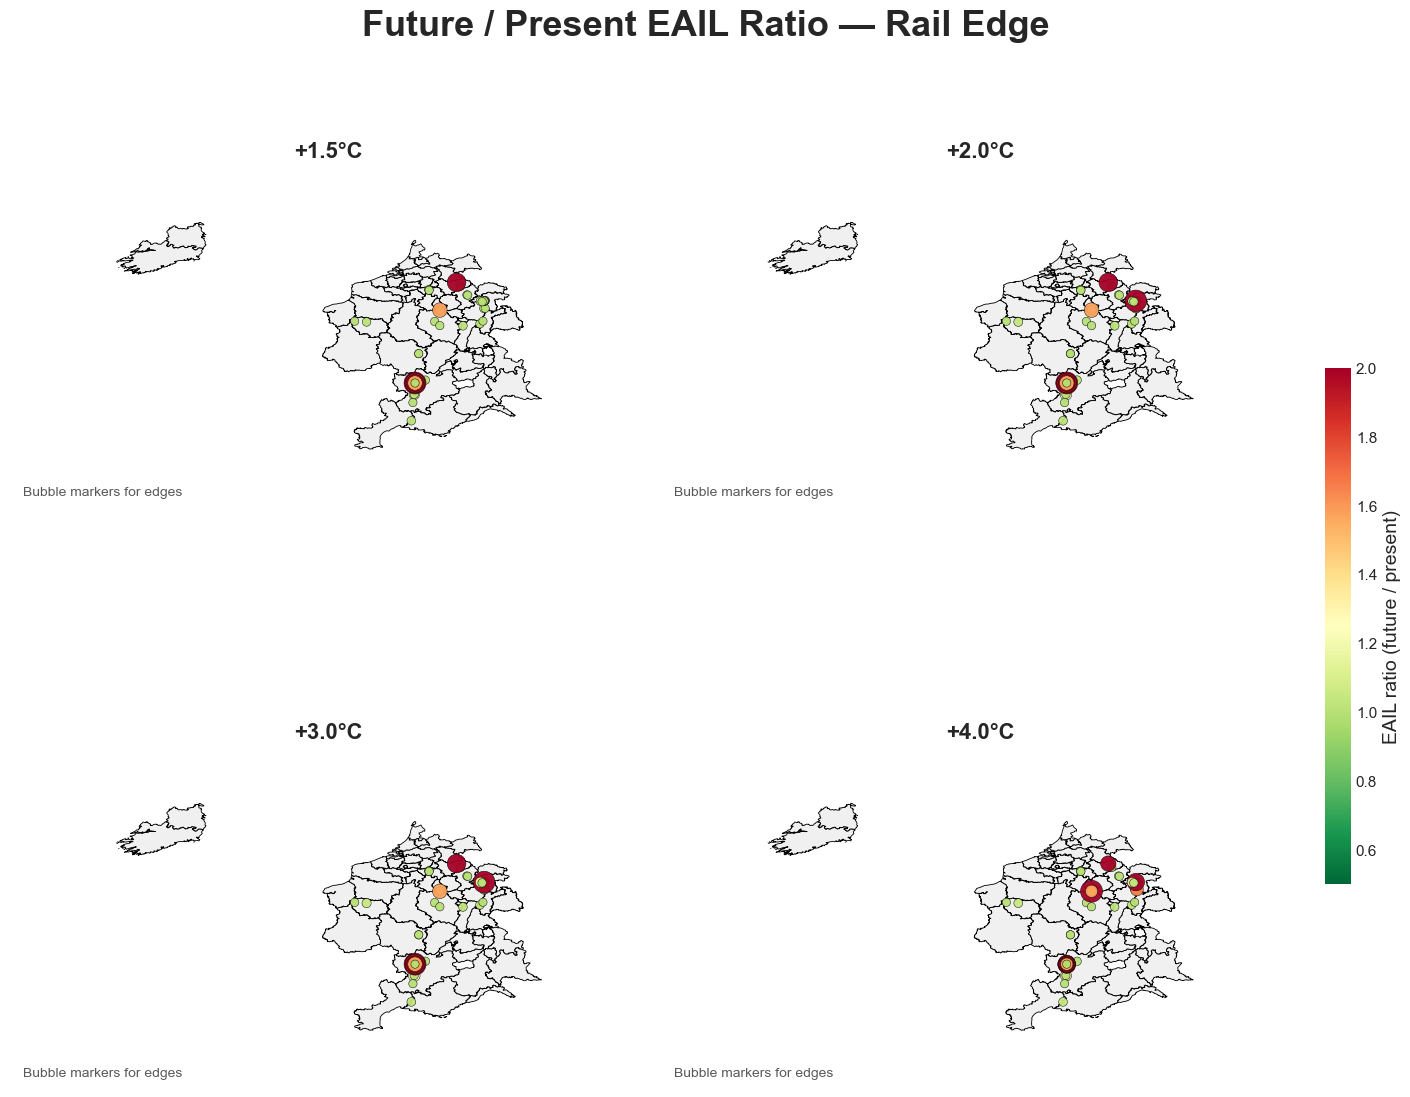

<Figure size 640x480 with 0 Axes>

In [ ]:
from pathlib import Path

if 'disruption_sectors' not in globals() or disruption_sectors is None or disruption_sectors.empty:
    raise ValueError('`disruption_sectors` is missing. Run enrichment first.')

future_pack = _corridor_utils.compute_future_present_eail_ratio_outputs(
    present_curve=present_curve,
    eal_by_infra=nonzero_eal_in_region,
    infra_geo=nonzero_infra_geo,
    nuts2=globals().get('nuts2'),
    basin_climate_file=Path(r"\\linux-filestore.ouce.ox.ac.uk\mistral\miraca\processed_data\Network_Risk\data\climate_hazards\basins_abs_shift_return_periods_lev08.parquet"),
    lev07_shp=Path(r"\\linux-filestore.ouce.ox.ac.uk\mistral\miraca\processed_data\Network_Risk\data\basin\hybas_lake_eu_lev07_v1c.shp"),
    lev08_shp=Path(r"\\linux-filestore.ouce.ox.ac.uk\mistral\miraca\processed_data\Network_Risk\data\basin\hybas_lake_eu_lev08_v1c.shp"),
    lev08_id_col='HYBAS_ID',
    plot_order=['rail edge'],
    plot_scenarios=['15', '20', '30', '40'],
    show=True,
)

basins_climate = future_pack['basins_climate']
rp_map = future_pack['rp_map']
basins_lev07 = future_pack['basins_lev07']
basins_lev08 = future_pack['basins_lev08']
infra_lev07 = future_pack['infra_lev07']
lev08_bridge = future_pack['lev08_bridge']
_infra_clim = future_pack['infra_clim']
present_curve = future_pack['present_curve_with_lev08']
ratio_df = future_pack['ratio_df']
ratio_geo = future_pack['ratio_geo']
eail_ratio_by_scenario = ratio_df.copy()
eail_ratio_geo = ratio_geo.copy()


plt.savefig(
    output_dir / 'future_eail_bubble_map.png', 
)

## 4.3 LAU-Level Loss Summary

This final section aggregates direct (EAD) and indirect (EAIL) losses by administrative units (LAU) and infrastructure type, enabling comparison of climate risk burdens across the corridor.

**Processing steps:**
1. **Load TENT hazard inputs**: Read climate hazard exposure files for each transport mode
2. **Spatial joins**: Link hazard exposure to infrastructure asset geometries
3. **Validate CRS**: Fix coordinate reference system mismatches before aggregation
4. **Aggregate by LAU**: Sum EAD and EAIL across all infrastructure within each LAU
5. **Visualize results**: Grouped/stacked bar charts comparing losses by country and mode

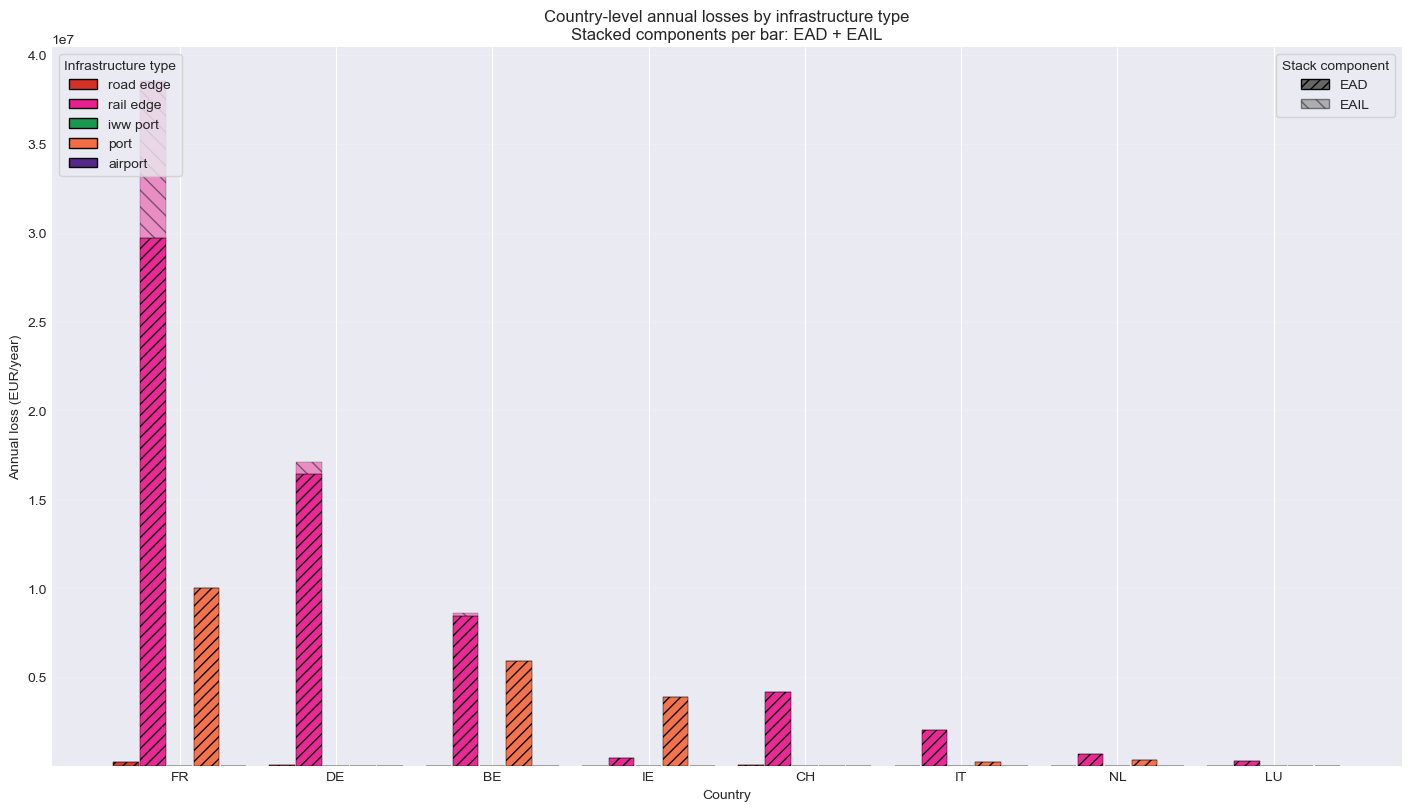

,country,infra_type,EAD,EAIL,total
0,FR,road edge,2.099259e+05,0.000000e+00,2.099259e+05
1,FR,rail edge,2.969770e+07,8.803151e+06,3.850085e+07
2,FR,iww port,3.306963e+02,0.000000e+00,3.306963e+02
3,FR,port,1.002283e+07,0.000000e+00,1.002283e+07
4,FR,airport,2.731277e+02,0.000000e+00,2.731277e+02
5,DE,road edge,5.978323e+04,0.000000e+00,5.978323e+04
6,DE,rail edge,1.644391e+07,6.658850e+05,1.710979e+07
7,DE,iww port,3.604615e+02,0.000000e+00,3.604615e+02
8,DE,airport,2.907322e+04,0.000000e+00,2.907322e+04
9,BE,road edge,1.906201e+04,0.000000e+00,1.906201e+04


<Figure size 640x480 with 0 Axes>

In [ ]:
from pathlib import Path

infra_cfg = {
    "road edge": {"haz_file": "TENT_roads_river.parquet", "haz_key": "id", "geo_var": "road_edges", "geo_cols": ["id"]},
    "rail edge": {"haz_file": "TENT_rail_river.parquet", "haz_key": "id", "geo_var": "rail_edges", "geo_cols": ["id"]},
    "iww port":  {"haz_file": "TENT_iww_river.parquet", "haz_key": "id", "geo_var": "iww_nodes", "geo_cols": ["id", "node_id", "port_id", "fid"]},
    "port":      {"haz_file": "TENT_ports_river.parquet", "haz_key": "port_name", "geo_var": "ports", "geo_cols": ["port_name", "name", "port_code", "id", "port_id", "fid"]},
    "airport":   {"haz_file": "TENT_airports_river.parquet", "haz_key": "icao", "geo_var": "airports", "geo_cols": ["icao", "id", "airport_id", "node_id", "fid"]},
}
infra_order = ["road edge", "rail edge", "iww port", "port", "airport"]
infra_colors = {
    "road edge": "#d73027",
    "rail edge": "#e91e90",
    "iww port": "#1a9850",
    "port": "#f46d43",
    "airport": "#542788",
}

infra_layers = {
    "road_edges": globals().get("road_edges"),
    "rail_edges": globals().get("rail_edges"),
    "iww_nodes": globals().get("iww_nodes"),
    "ports": globals().get("ports"),
    "airports": globals().get("airports"),
}

plot_df = build_country_loss_plot_df(
    present_eal=present_eal,
    nuts2=nuts2,
    haz_dir=impact_dir,
    infra_cfg=infra_cfg,
    infra_order=infra_order,
    infra_layers=infra_layers,
)

_ = plot_country_loss_grouped_bars(
    plot_df=plot_df,
    infra_order=infra_order,
    infra_colors=infra_colors,
)

display(
    plot_df[["country", "infra_type", "EAD", "EAIL", "total"]]
    .sort_values(["country", "infra_type"])
    .reset_index(drop=True)
)

plt.savefig(
    output_dir / 'country_loss_grouped_bars.png',
)

# 5 LAU-Level Risk Aggregation: Direct and Indirect Losses

This section spatially matches infrastructure assets (railways, roads, ports, airports) to Local Administrative Units (LAU) and aggregates climate risk by LAU.

**Aggregation logic:**
- **EAD (Expected Annual Damage)**: Sum of direct damages from all infrastructure within each LAU
- **EAIL (Expected Annual Indirect Loss)**: Maximum indirect loss value within each LAU (representing the most vulnerable supply chain in that administrative unit)

**Map interpretation:**
- Left panel: Total annual direct infrastructure damage burden by LAU
- Right panel: Greatest supply-chain disruption risk by LAU (single worst-case scenario per LAU)

This aggregation enables policy prioritization at the administrative level for adaptation and resilience investment.

LAU boundaries loaded: 97,987 features
  file: \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\inputs\country_data\Corridors_NUTS2\rhine-alpine\LAU_2024.parquet
  columns: ['GISCO_ID', 'CNTR_CODE', 'LAU_NAME', 'POP_2024', 'POP_DENS_2024', 'AREA_KM2', 'YEAR', 'geometry']
LAUs matched to selected NUTS2: 32,600 / 97,987
LAUs matched to selected NUTS2: 32,600 / 97,987
Combined EAD assets: 167,910 (1 types)
Combined EAIL assets (from present-day EAIL): 66 (1 types)
Combined EAD assets: 167,910 (1 types)
Combined EAIL assets (from present-day EAIL): 66 (1 types)

EAD by LAU: 2,332 LAUs with assets (sum aggregation)
EAIL by LAU: 32 LAUs with assets
Shared color scale across EAD/EAIL: min=0, max=7,000,000
Bubble-size cap: max marker size corresponds to €7,000,000
Non-zero EAD bubbles to plot: 2,332
Non-zero EAIL bubbles to plot: 32

EAD by LAU: 2,332 LAUs with assets (sum aggregation)
EAIL by LAU: 32 LAUs with assets
Shared color scale across EAD/EAIL: min=0, max=7,000,000
Bu

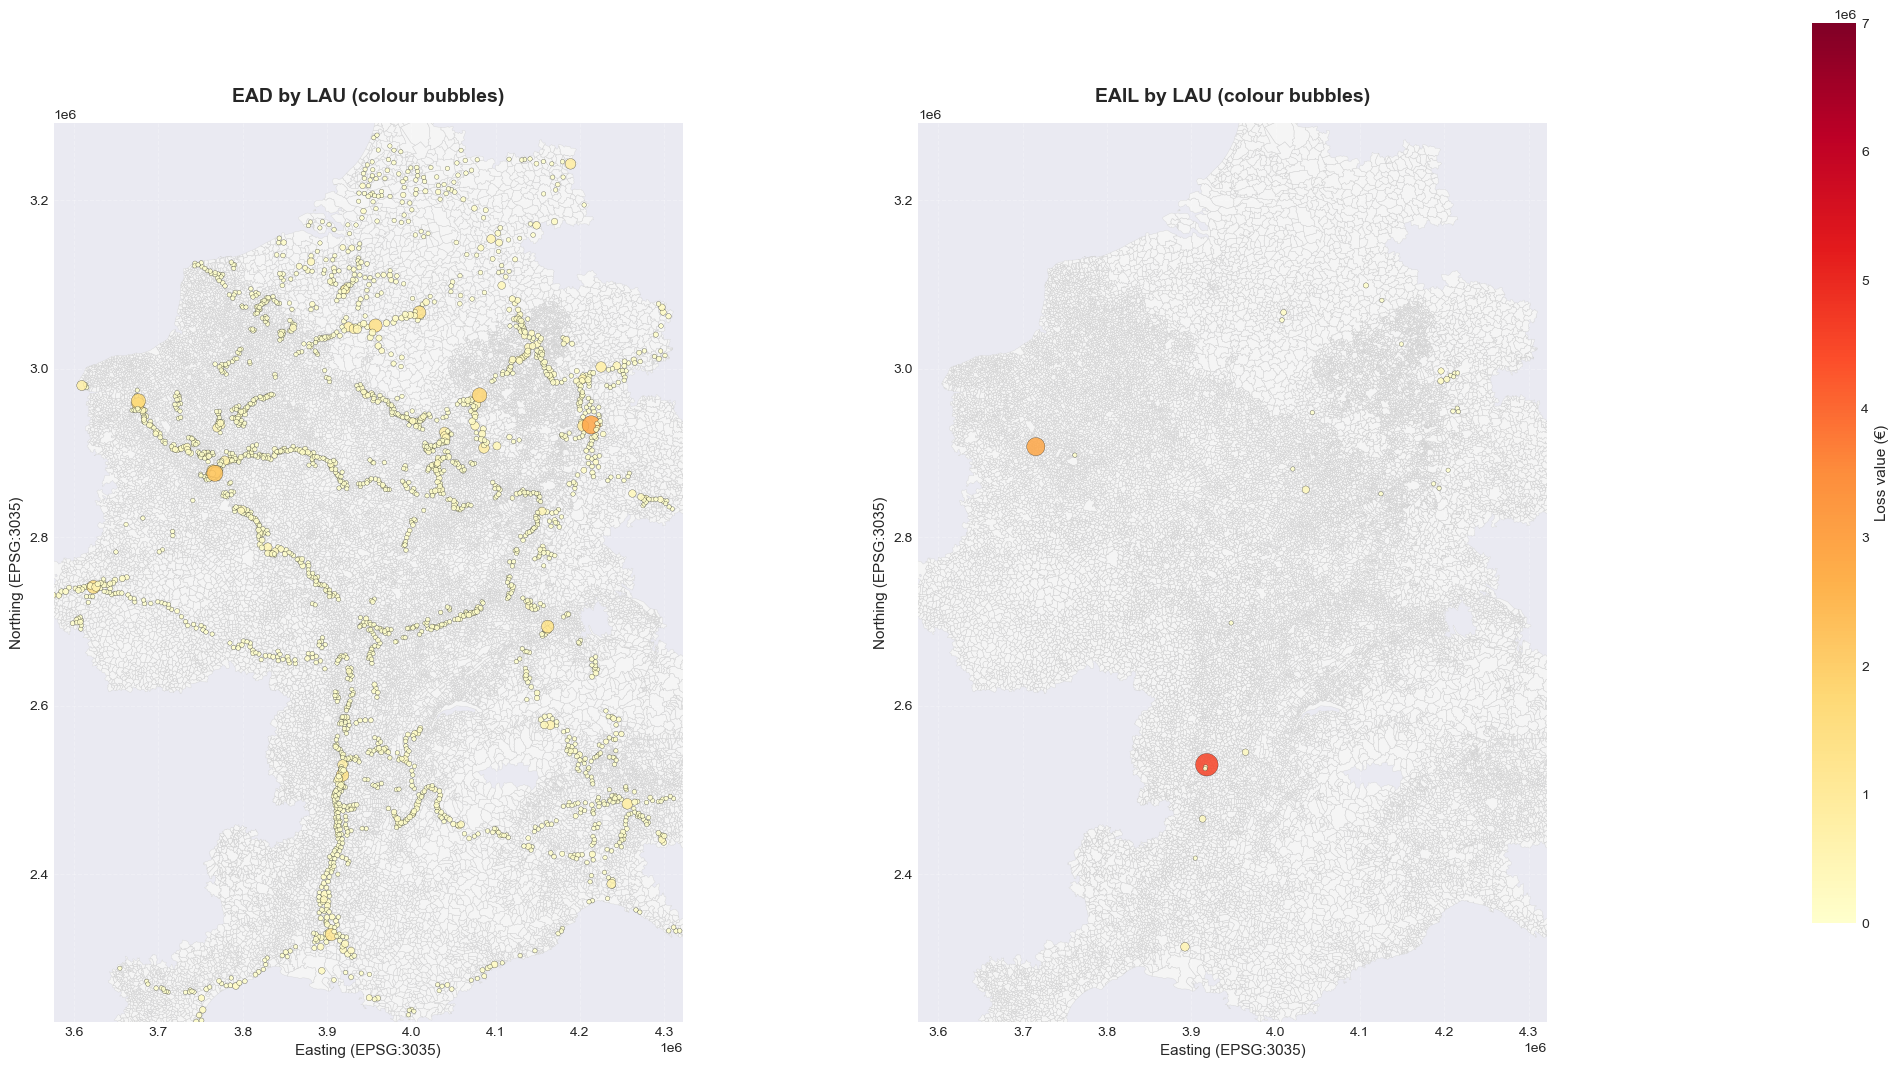


=== LAU Aggregation Summary ===
EAD by LAU:
  Total EAD: €134,483,582
  Mean per LAU: €4,125
  Max per LAU: €2,936,957
  LAUs with exposure: 2,332

EAIL by LAU (sum):
  Total: €9,648,829
  Mean per LAU: €296
  Max per LAU: €4,557,406
  LAUs with exposure: 32

Aggregated results saved: \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\outputs\lau_ead_eail_aggregated.shp

Aggregated results saved: \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\outputs\lau_ead_eail_aggregated.shp
Summary table saved: \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\outputs\lau_ead_eail_summary.csv
Summary table saved: \\linux-filestore.ouce.ox.ac.uk\cenv0972\AFP_python\JN-MIRACA\UC1\outputs\lau_ead_eail_summary.csv


In [ ]:
# ── LAU Aggregation and Visualization (utility-driven) ──────────────────────
import warnings
warnings.filterwarnings('ignore')

lau_pack = _corridor_utils.run_lau_ead_eail_aggregation(
    selected_nuts_dir=selected_nuts_dir,
    country_data_dir=country_data_dir,
    country_data_dir_local=country_data_dir_local,
    root=root,
    code_dir=code_dir,
    output_dir=output_dir,
    nuts2=globals().get('nuts2'),
    globals_dict=globals(),
)

lau_gdf_plot = lau_pack['lau_gdf_plot']
lau_gdf = lau_pack['lau_gdf']
ead_combined = lau_pack['ead_combined']
eail_combined = lau_pack['eail_combined']
ead_by_lau = lau_pack['ead_by_lau']
eail_by_lau = lau_pack['eail_by_lau']
lau_file = lau_pack['lau_file']